In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Project folder
PROJECT_DIR = "/content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation"

# Check whether the folder exists
if os.path.exists(PROJECT_DIR):
    print("✅ Project folder found!")
    print("📁", PROJECT_DIR)
else:
    print("❌ Project folder not found!")
    print("Please check the folder name in Google Drive.")

Mounted at /content/drive
✅ Project folder found!
📁 /content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation


In [ ]:
# ============================================================
# CELL 2: SIMULATION CONFIGURATION
# Smart Rehabilitation Wristband
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------
# Simulation size
# ------------------------------------------------------------

NUM_SESSIONS = 1000

# Duration of each rehabilitation session
SESSION_DURATION_SEC = 300       # 5 minutes

# Simulation sampling interval
SIMULATION_STEP_SEC = 1          # 1-second resolution

# Number of time points per session
TIME_POINTS = np.arange(
    0,
    SESSION_DURATION_SEC + SIMULATION_STEP_SEC,
    SIMULATION_STEP_SEC
)

# ------------------------------------------------------------
# Warm-up period
# ------------------------------------------------------------

WARMUP_SEC = 60

# ------------------------------------------------------------
# Existing alert thresholds
# ------------------------------------------------------------

FATIGUE_THRESHOLD = 85
HR_STRAIN_THRESHOLD = 140
READINESS_THRESHOLD = 0.6

# ------------------------------------------------------------
# Scenario types
# ------------------------------------------------------------

SCENARIOS = [
    "Normal",
    "High_Fatigue",
    "Physiological_Overload",
    "Poor_Movement",
    "Combined_Adverse"
]

print("=" * 60)
print("SMART REHABILITATION WRISTBAND")
print("SIMULATION CONFIGURATION")
print("=" * 60)

print(f"Number of sessions       : {NUM_SESSIONS}")
print(f"Session duration         : {SESSION_DURATION_SEC} sec")
print(f"Simulation resolution    : {SIMULATION_STEP_SEC} sec")
print(f"Warm-up period           : {WARMUP_SEC} sec")

print("\nAlert thresholds:")
print(f"Fatigue threshold        : F > {FATIGUE_THRESHOLD}")
print(f"HR strain threshold      : H > {HR_STRAIN_THRESHOLD}")
print(f"Readiness threshold      : Q < {READINESS_THRESHOLD}")

print("\nSimulation scenarios:")
for i, scenario in enumerate(SCENARIOS, 1):
    print(f"{i}. {scenario}")

print("\n✅ Configuration loaded successfully!")

SMART REHABILITATION WRISTBAND
SIMULATION CONFIGURATION
Number of sessions       : 1000
Session duration         : 300 sec
Simulation resolution    : 1 sec
Warm-up period           : 60 sec

Alert thresholds:
Fatigue threshold        : F > 85
HR strain threshold      : H > 140
Readiness threshold      : Q < 0.6

Simulation scenarios:
1. Normal
2. High_Fatigue
3. Physiological_Overload
4. Poor_Movement
5. Combined_Adverse

✅ Configuration loaded successfully!


In [ ]:
# ============================================================
# CELL 3: SCENARIO DEFINITIONS
# ============================================================

SCENARIO_CONFIG = {

    "Normal": {
        "description": "Normal rehabilitation exercise",
        "dexterity_range": (0.70, 0.95),
        "fatigue_range": (5, 45),
        "hr_strain_range": (50, 100),
        "movement_quality": "good"
    },

    "High_Fatigue": {
        "description": "Progressively increasing muscular fatigue",
        "dexterity_range": (0.50, 0.85),
        "fatigue_range": (40, 100),
        "hr_strain_range": (70, 120),
        "movement_quality": "degrading"
    },

    "Physiological_Overload": {
        "description": "Elevated physiological load",
        "dexterity_range": (0.60, 0.90),
        "fatigue_range": (50, 100),
        "hr_strain_range": (100, 160),
        "movement_quality": "moderate"
    },

    "Poor_Movement": {
        "description": "Reduced movement quality during exercise",
        "dexterity_range": (0.20, 0.60),
        "fatigue_range": (20, 70),
        "hr_strain_range": (50, 100),
        "movement_quality": "poor"
    },

    "Combined_Adverse": {
        "description": "Poor movement combined with high physiological load",
        "dexterity_range": (0.20, 0.60),
        "fatigue_range": (60, 100),
        "hr_strain_range": (100, 160),
        "movement_quality": "poor"
    }
}

print("=" * 60)
print("SCENARIO DEFINITIONS")
print("=" * 60)

for name, config in SCENARIO_CONFIG.items():

    print(f"\n{name}")
    print("-" * len(name))

    print(f"Description       : {config['description']}")
    print(f"Dexterity range   : {config['dexterity_range']}")
    print(f"Fatigue range     : {config['fatigue_range']}")
    print(f"HR strain range   : {config['hr_strain_range']}")
    print(f"Movement quality  : {config['movement_quality']}")

print("\n✅ Scenario definitions loaded successfully!")

SCENARIO DEFINITIONS

Normal
------
Description       : Normal rehabilitation exercise
Dexterity range   : (0.7, 0.95)
Fatigue range     : (5, 45)
HR strain range   : (50, 100)
Movement quality  : good

High_Fatigue
------------
Description       : Progressively increasing muscular fatigue
Dexterity range   : (0.5, 0.85)
Fatigue range     : (40, 100)
HR strain range   : (70, 120)
Movement quality  : degrading

Physiological_Overload
----------------------
Description       : Elevated physiological load
Dexterity range   : (0.6, 0.9)
Fatigue range     : (50, 100)
HR strain range   : (100, 160)
Movement quality  : moderate

Poor_Movement
-------------
Description       : Reduced movement quality during exercise
Dexterity range   : (0.2, 0.6)
Fatigue range     : (20, 70)
HR strain range   : (50, 100)
Movement quality  : poor

Combined_Adverse
----------------
Description       : Poor movement combined with high physiological load
Dexterity range   : (0.2, 0.6)
Fatigue range     : (60, 100

In [ ]:
# ============================================================
# CELL 4: GENERATE ONE SIMULATED SESSION
# ============================================================

def generate_session(scenario, session_id=1):
    """
    Generate one time-varying simulated rehabilitation session.

    Variables:
        R = repetition count
        D = dexterity score
        F = muscle fatigue
        H = heart-rate strain
    """

    rng = np.random.default_rng(RANDOM_SEED + session_id)

    t = TIME_POINTS.copy()
    n = len(t)

    config = SCENARIO_CONFIG[scenario]

    # --------------------------------------------------------
    # 1. Repetition count
    # --------------------------------------------------------
    # Repetitions accumulate mainly after the warm-up period.
    R = np.zeros(n)

    exercise_start = WARMUP_SEC

    for i in range(1, n):

        if t[i] >= exercise_start:

            # Probability of completing a repetition
            # slightly decreases in adverse conditions.
            if scenario == "Normal":
                rep_probability = 0.22

            elif scenario == "High_Fatigue":
                rep_probability = 0.18

            elif scenario == "Physiological_Overload":
                rep_probability = 0.17

            elif scenario == "Poor_Movement":
                rep_probability = 0.15

            else:  # Combined_Adverse
                rep_probability = 0.13

            if rng.random() < rep_probability:
                R[i] = R[i-1] + 1
            else:
                R[i] = R[i-1]

        else:
            R[i] = 0

    # --------------------------------------------------------
    # 2. Dexterity score
    # --------------------------------------------------------

    d_low, d_high = config["dexterity_range"]

    # Start near the middle of the scenario range.
    D_base = rng.uniform(d_low, d_high)

    # Small temporal variation.
    noise_D = rng.normal(0, 0.015, n)

    # Scenario-dependent degradation.
    degradation = np.zeros(n)

    if config["movement_quality"] in ["degrading", "poor"]:
        exercise_fraction = np.clip(
            (t - exercise_start) /
            max(1, SESSION_DURATION_SEC - exercise_start),
            0,
            1
        )

        if config["movement_quality"] == "degrading":
            degradation = 0.15 * exercise_fraction
        else:
            degradation = 0.05 * exercise_fraction

    D = D_base - degradation + noise_D
    D = np.clip(D, d_low, d_high)

    # --------------------------------------------------------
    # 3. Muscle fatigue
    # --------------------------------------------------------

    f_low, f_high = config["fatigue_range"]

    exercise_fraction = np.clip(
        (t - exercise_start) /
        max(1, SESSION_DURATION_SEC - exercise_start),
        0,
        1
    )

    if scenario == "Normal":
        F = f_low + (f_high - f_low) * exercise_fraction * 0.7

    elif scenario == "High_Fatigue":
        F = f_low + (f_high - f_low) * exercise_fraction

    elif scenario == "Physiological_Overload":
        F = f_low + (f_high - f_low) * exercise_fraction * 0.85

    elif scenario == "Poor_Movement":
        F = f_low + (f_high - f_low) * exercise_fraction * 0.65

    else:  # Combined_Adverse
        F = f_low + (f_high - f_low) * exercise_fraction

    F += rng.normal(0, 2.0, n)
    F = np.clip(F, f_low, f_high)

    # --------------------------------------------------------
    # 4. Heart-rate strain
    # --------------------------------------------------------

    h_low, h_high = config["hr_strain_range"]

    if scenario == "Normal":
        H = h_low + (h_high - h_low) * exercise_fraction * 0.7

    elif scenario == "High_Fatigue":
        H = h_low + (h_high - h_low) * exercise_fraction * 0.75

    elif scenario == "Physiological_Overload":
        H = h_low + (h_high - h_low) * exercise_fraction

    elif scenario == "Poor_Movement":
        H = h_low + (h_high - h_low) * exercise_fraction * 0.7

    else:  # Combined_Adverse
        H = h_low + (h_high - h_low) * exercise_fraction

    H += rng.normal(0, 2.5, n)
    H = np.clip(H, h_low, h_high)

    # --------------------------------------------------------
    # 5. Warm-up reset
    # --------------------------------------------------------

    warmup_mask = t < WARMUP_SEC

    D[warmup_mask] = np.clip(
        D_base + rng.normal(0, 0.01, warmup_mask.sum()),
        d_low,
        d_high
    )

    F[warmup_mask] = 0
    H[warmup_mask] = 0

    # --------------------------------------------------------
    # Create DataFrame
    # --------------------------------------------------------

    df = pd.DataFrame({
        "session_id": session_id,
        "time_sec": t,
        "scenario": scenario,
        "repetitionCount": R.astype(int),
        "dexterityScore": D,
        "muscleFatigue": F,
        "heartRateStrain": H
    })

    return df


# ------------------------------------------------------------
# Generate one example session
# ------------------------------------------------------------

example_session = generate_session(
    scenario="High_Fatigue",
    session_id=1
)

print("=" * 70)
print("ONE SIMULATED SESSION")
print("=" * 70)

print("\nShape:", example_session.shape)

print("\nFirst 10 rows:")
display(example_session.head(10))

print("\nLast 10 rows:")
display(example_session.tail(10))

print("\nSummary:")
display(
    example_session[
        [
            "repetitionCount",
            "dexterityScore",
            "muscleFatigue",
            "heartRateStrain"
        ]
    ].describe()
)

print("\n✅ One simulated session generated successfully!")

ONE SIMULATED SESSION

Shape: (301, 7)

First 10 rows:


,session_id,time_sec,scenario,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
0,1,0,High_Fatigue,0,0.848906,0.0,0.0
1,1,1,High_Fatigue,0,0.844550,0.0,0.0
2,1,2,High_Fatigue,0,0.828335,0.0,0.0
3,1,3,High_Fatigue,0,0.839496,0.0,0.0
4,1,4,High_Fatigue,0,0.848997,0.0,0.0
5,1,5,High_Fatigue,0,0.850000,0.0,0.0
6,1,6,High_Fatigue,0,0.842121,0.0,0.0
7,1,7,High_Fatigue,0,0.838503,0.0,0.0
8,1,8,High_Fatigue,0,0.838299,0.0,0.0
9,1,9,High_Fatigue,0,0.845623,0.0,0.0



Last 10 rows:


,session_id,time_sec,scenario,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
291,1,291,High_Fatigue,43,0.686414,97.570394,103.647619
292,1,292,High_Fatigue,44,0.716553,97.958561,106.158516
293,1,293,High_Fatigue,44,0.699335,100.000000,111.153221
294,1,294,High_Fatigue,44,0.677548,97.972372,108.831950
295,1,295,High_Fatigue,44,0.715871,97.763904,105.534824
296,1,296,High_Fatigue,45,0.667662,100.000000,113.157278
297,1,297,High_Fatigue,45,0.698235,100.000000,109.658378
298,1,298,High_Fatigue,46,0.683525,100.000000,105.086394
299,1,299,High_Fatigue,46,0.714666,97.474636,106.204538
300,1,300,High_Fatigue,46,0.702970,100.000000,110.126848



Summary:


,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
count,301.000000,301.000000,301.000000,301.000000
mean,16.408638,0.780634,56.082289,71.014928
std,13.442313,0.050887,32.111655,36.873309
min,0.000000,0.667662,0.000000,0.000000
25%,3.000000,0.737801,43.840045,71.754073
50%,16.000000,0.782374,62.816281,84.451391
75%,25.000000,0.828335,82.456573,95.557051
max,46.000000,0.850000,100.000000,113.157278



✅ One simulated session generated successfully!


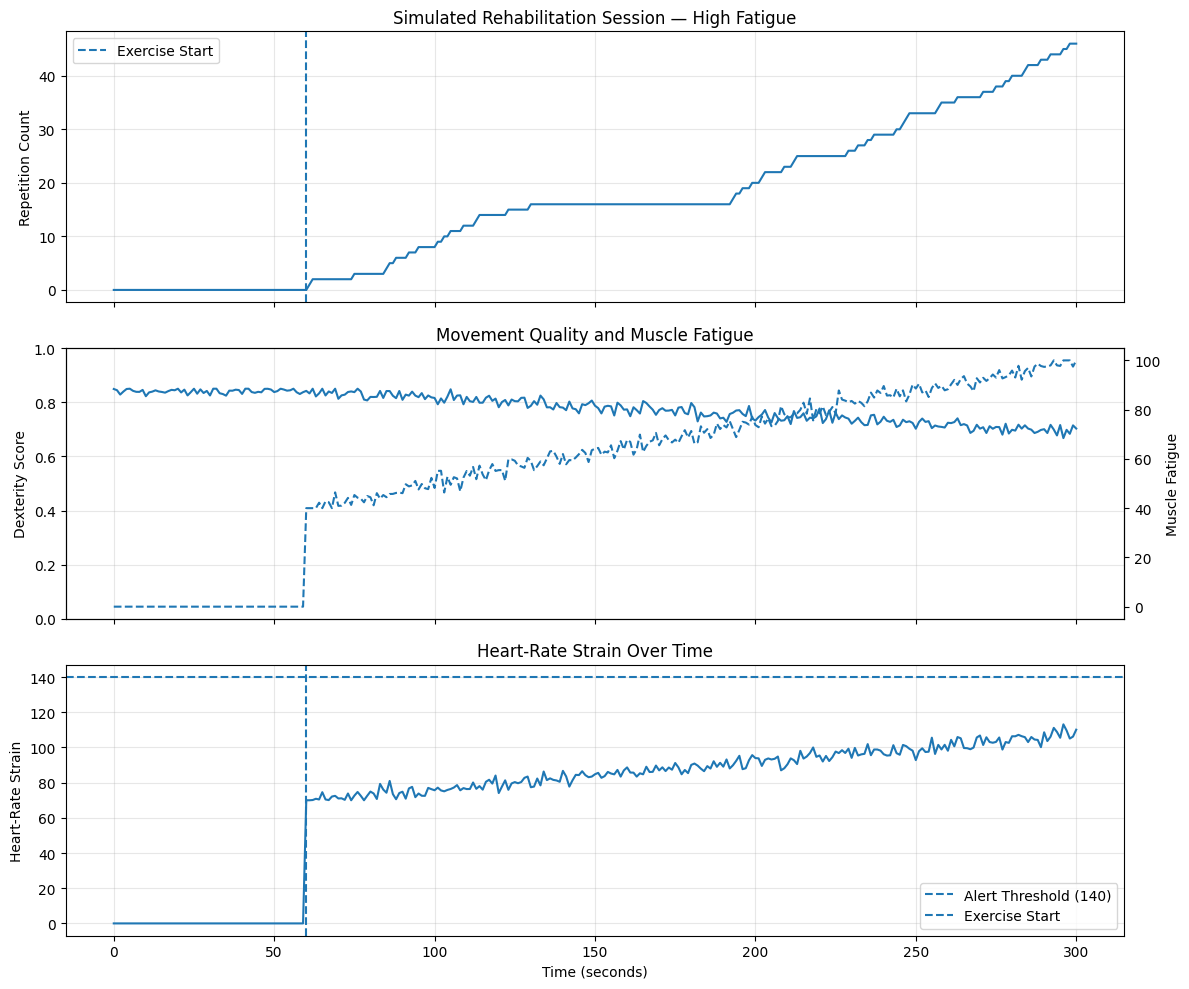

In [ ]:
# ============================================================
# CELL 5: VISUALIZE ONE SIMULATED SESSION
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ------------------------------------------------------------
# Plot 1: Repetition Count
# ------------------------------------------------------------

axes[0].plot(
    example_session["time_sec"],
    example_session["repetitionCount"]
)

axes[0].axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

axes[0].set_ylabel("Repetition Count")
axes[0].set_title("Simulated Rehabilitation Session — High Fatigue")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 2: Dexterity + Fatigue
# ------------------------------------------------------------

ax2 = axes[1]

ax2.plot(
    example_session["time_sec"],
    example_session["dexterityScore"],
    label="Dexterity Score"
)

ax2.set_ylabel("Dexterity Score")
ax2.set_ylim(0, 1)

ax2b = ax2.twinx()

ax2b.plot(
    example_session["time_sec"],
    example_session["muscleFatigue"],
    linestyle="--",
    label="Muscle Fatigue"
)

ax2b.set_ylabel("Muscle Fatigue")

ax2.set_title("Movement Quality and Muscle Fatigue")
ax2.grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 3: Heart-rate strain
# ------------------------------------------------------------

axes[2].plot(
    example_session["time_sec"],
    example_session["heartRateStrain"]
)

axes[2].axhline(
    HR_STRAIN_THRESHOLD,
    linestyle="--",
    label=f"Alert Threshold ({HR_STRAIN_THRESHOLD})"
)

axes[2].axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Heart-Rate Strain")
axes[2].set_title("Heart-Rate Strain Over Time")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ONE SIMULATED REHABILITATION SESSION

Scenario       : High_Fatigue
Time points    : 301
Duration       : 300 seconds

First 10 rows:


,session_id,time_sec,scenario,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
0,1,0,High_Fatigue,0,0.851777,2.715791,7.558737
1,1,1,High_Fatigue,0,0.843856,4.039534,4.951505
2,1,2,High_Fatigue,0,0.851140,4.219726,6.242230
3,1,3,High_Fatigue,0,0.849723,2.714708,6.514842
4,1,4,High_Fatigue,0,0.859075,3.133187,4.254711
5,1,5,High_Fatigue,0,0.849162,3.602982,5.581767
6,1,6,High_Fatigue,0,0.845799,3.489684,5.988058
7,1,7,High_Fatigue,0,0.865302,3.168854,3.636264
8,1,8,High_Fatigue,0,0.833786,2.892906,7.463144
9,1,9,High_Fatigue,0,0.858955,2.299955,4.941782



Last 10 rows:


,session_id,time_sec,scenario,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
291,1,291,High_Fatigue,35,0.704444,92.805997,111.419524
292,1,292,High_Fatigue,35,0.671749,91.993101,116.222484
293,1,293,High_Fatigue,35,0.725218,94.987843,113.795184
294,1,294,High_Fatigue,35,0.731806,97.789758,119.470010
295,1,295,High_Fatigue,35,0.728445,98.746879,116.523947
296,1,296,High_Fatigue,35,0.693271,93.825230,117.561142
297,1,297,High_Fatigue,35,0.707617,93.210445,114.835198
298,1,298,High_Fatigue,35,0.708632,96.913959,115.097085
299,1,299,High_Fatigue,36,0.677713,100.000000,120.006462
300,1,300,High_Fatigue,36,0.702707,100.000000,113.865121



Summary:


,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
count,301.000000,301.000000,301.000000,301.000000
mean,14.607973,0.789920,42.754472,75.349428
std,11.979669,0.050992,31.682432,37.150372
min,0.000000,0.671749,0.046945,0.823047
25%,2.000000,0.744034,10.807000,71.673510
50%,14.000000,0.795508,40.743335,86.861942
75%,25.000000,0.838976,72.227242,101.096236
max,36.000000,0.873164,100.000000,120.189615


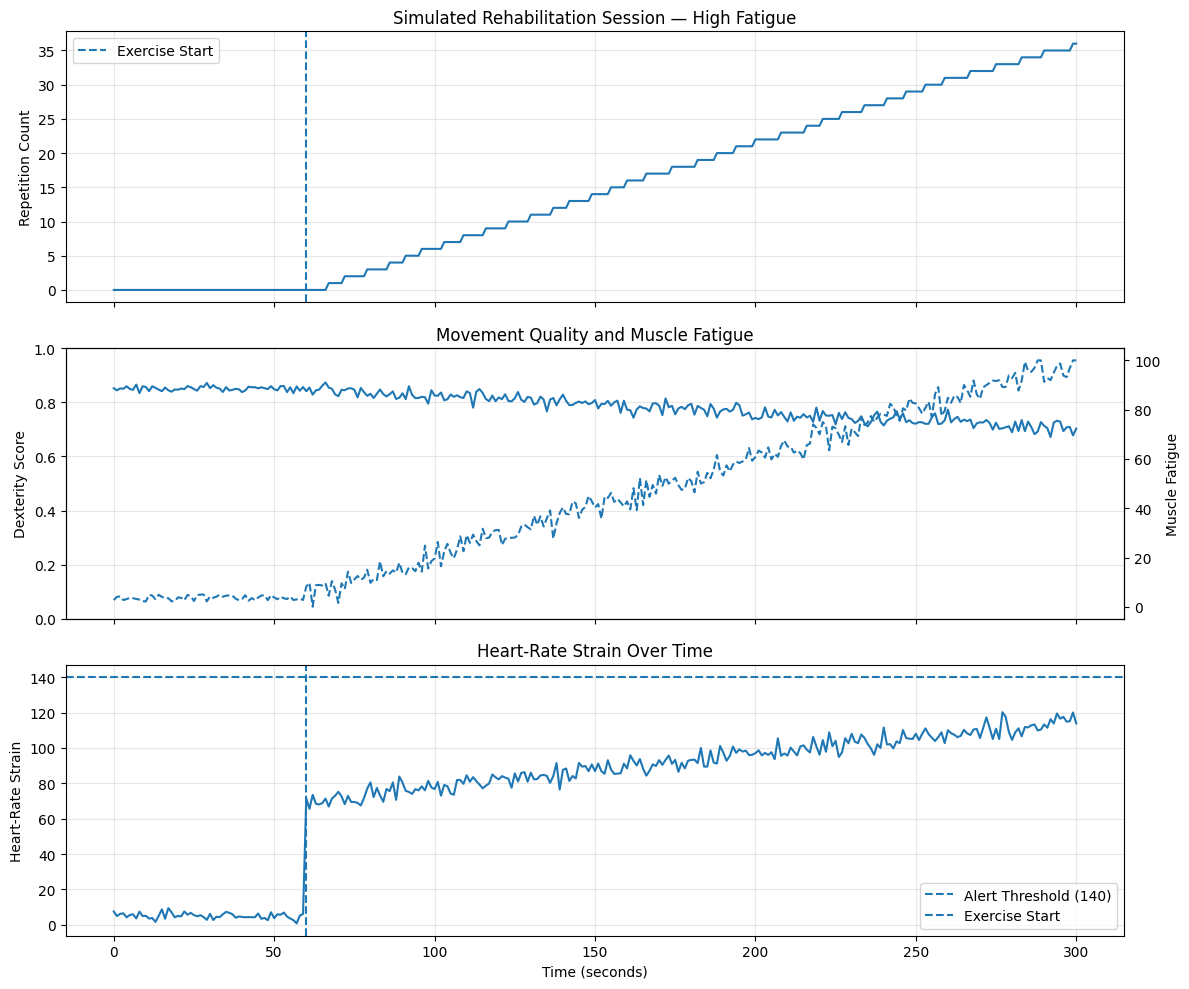


✅ One-session simulation and visualization completed!


In [ ]:
# ============================================================
# CELL 4: ONE-SESSION SIMULATION + VISUALIZATION
# Smart Rehabilitation Wristband
# ============================================================

# ------------------------------------------------------------
# Generate one High-Fatigue rehabilitation session
# ------------------------------------------------------------

scenario = "High_Fatigue"

# Create time array
time = TIME_POINTS

# Initialize arrays
repetition_count = np.zeros(len(time))
dexterity = np.zeros(len(time))
fatigue = np.zeros(len(time))
hr_strain = np.zeros(len(time))

# ------------------------------------------------------------
# 1. Repetition generation
# ------------------------------------------------------------

# No repetitions during warm-up.
# After warm-up, repetitions occur at variable intervals.

current_reps = 0
next_rep_time = WARMUP_SEC + np.random.randint(5, 9)

for i, t in enumerate(time):

    if t >= next_rep_time:

        current_reps += 1

        # Variable interval between repetitions
        # Slightly slower movement as fatigue increases
        fatigue_effect = min(current_reps / 50, 1.0)

        interval = np.random.randint(
            5 + int(2 * fatigue_effect),
            8 + int(3 * fatigue_effect)
        )

        next_rep_time = t + interval

    repetition_count[i] = current_reps


# ------------------------------------------------------------
# 2. Dexterity score
# ------------------------------------------------------------

for i, t in enumerate(time):

    if t < WARMUP_SEC:

        # Stable baseline during warm-up
        dexterity[i] = 0.85 + np.random.normal(0, 0.008)

    else:

        # Gradual degradation after exercise begins
        exercise_time = t - WARMUP_SEC
        progress = exercise_time / (
            SESSION_DURATION_SEC - WARMUP_SEC
        )

        base_dexterity = 0.85 - (0.15 * progress)

        dexterity[i] = (
            base_dexterity
            + np.random.normal(0, 0.015)
        )

# Keep dexterity within [0, 1]
dexterity = np.clip(dexterity, 0, 1)


# ------------------------------------------------------------
# 3. Muscle fatigue
# ------------------------------------------------------------

for i, t in enumerate(time):

    if t < WARMUP_SEC:

        # Low fatigue during warm-up
        fatigue[i] = np.random.uniform(2, 5)

    else:

        exercise_time = t - WARMUP_SEC

        progress = exercise_time / (
            SESSION_DURATION_SEC - WARMUP_SEC
        )

        # Gradual fatigue increase
        base_fatigue = 5 + (95 * progress)

        fatigue[i] = (
            base_fatigue
            + np.random.normal(0, 3)
        )

# Keep fatigue within 0–100
fatigue = np.clip(fatigue, 0, 100)


# ------------------------------------------------------------
# 4. Heart-rate strain
# ------------------------------------------------------------

for i, t in enumerate(time):

    if t < WARMUP_SEC:

        # Low baseline before exercise
        hr_strain[i] = np.random.normal(5, 1.5)

    else:

        exercise_time = t - WARMUP_SEC

        progress = exercise_time / (
            SESSION_DURATION_SEC - WARMUP_SEC
        )

        # Gradual HR strain increase
        base_hr = 70 + (45 * progress)

        hr_strain[i] = (
            base_hr
            + np.random.normal(0, 3)
        )

# Keep values non-negative
hr_strain = np.clip(hr_strain, 0, None)


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

example_session = pd.DataFrame({

    "session_id": 1,
    "time_sec": time,
    "scenario": scenario,
    "repetitionCount": repetition_count.astype(int),
    "dexterityScore": dexterity,
    "muscleFatigue": fatigue,
    "heartRateStrain": hr_strain

})


# ============================================================
# PRINT DATA INFORMATION
# ============================================================

print("=" * 65)
print("ONE SIMULATED REHABILITATION SESSION")
print("=" * 65)

print(f"\nScenario       : {scenario}")
print(f"Time points    : {len(example_session)}")
print(f"Duration       : {SESSION_DURATION_SEC} seconds")

print("\nFirst 10 rows:")
display(example_session.head(10))

print("\nLast 10 rows:")
display(example_session.tail(10))

print("\nSummary:")
display(
    example_session[
        [
            "repetitionCount",
            "dexterityScore",
            "muscleFatigue",
            "heartRateStrain"
        ]
    ].describe()
)


# ============================================================
# VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 10),
    sharex=True
)

# ------------------------------------------------------------
# Plot 1: Repetition Count
# ------------------------------------------------------------

axes[0].plot(
    example_session["time_sec"],
    example_session["repetitionCount"]
)

axes[0].axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

axes[0].set_ylabel("Repetition Count")
axes[0].set_title(
    "Simulated Rehabilitation Session — High Fatigue"
)

axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 2: Dexterity + Fatigue
# ------------------------------------------------------------

ax2 = axes[1]

ax2.plot(
    example_session["time_sec"],
    example_session["dexterityScore"],
    label="Dexterity Score"
)

ax2.set_ylabel("Dexterity Score")
ax2.set_ylim(0, 1)

ax2b = ax2.twinx()

ax2b.plot(
    example_session["time_sec"],
    example_session["muscleFatigue"],
    linestyle="--",
    label="Muscle Fatigue"
)

ax2b.set_ylabel("Muscle Fatigue")

ax2.set_title(
    "Movement Quality and Muscle Fatigue"
)

ax2.grid(True, alpha=0.3)


# ------------------------------------------------------------
# Plot 3: Heart-rate strain
# ------------------------------------------------------------

axes[2].plot(
    example_session["time_sec"],
    example_session["heartRateStrain"]
)

axes[2].axhline(
    HR_STRAIN_THRESHOLD,
    linestyle="--",
    label=f"Alert Threshold ({HR_STRAIN_THRESHOLD})"
)

axes[2].axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("Heart-Rate Strain")
+
axes[2].set_title(
    "Heart-Rate Strain Over Time"
)

axes[2].legend()
axes[2].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


print("\n✅ One-session simulation and visualization completed!")

FIVE-SCENARIO SIMULATION COMPARISON


,Scenario,Final_Repetitions,Mean_Dexterity,Final_Dexterity,Final_Fatigue,Final_HR_Strain,Max_HR_Strain
0,Normal,39,0.871,0.798,39.072,92.744,100.638
1,High_Fatigue,33,0.791,0.688,100.000,121.500,124.482
2,Physiological_Overload,36,0.810,0.758,93.356,157.769,164.326
3,Poor_Movement,27,0.541,0.284,67.165,102.292,107.210
4,Combined_Adverse,24,0.490,0.260,100.000,157.310,163.661



Final values for each scenario:
----------------------------------------------------------------------
Normal                    | R= 39 | D=0.798 | F= 39.07 | H= 92.74
High_Fatigue              | R= 33 | D=0.688 | F=100.00 | H=121.50
Physiological_Overload    | R= 36 | D=0.758 | F= 93.36 | H=157.77
Poor_Movement             | R= 27 | D=0.284 | F= 67.17 | H=102.29
Combined_Adverse          | R= 24 | D=0.260 | F=100.00 | H=157.31


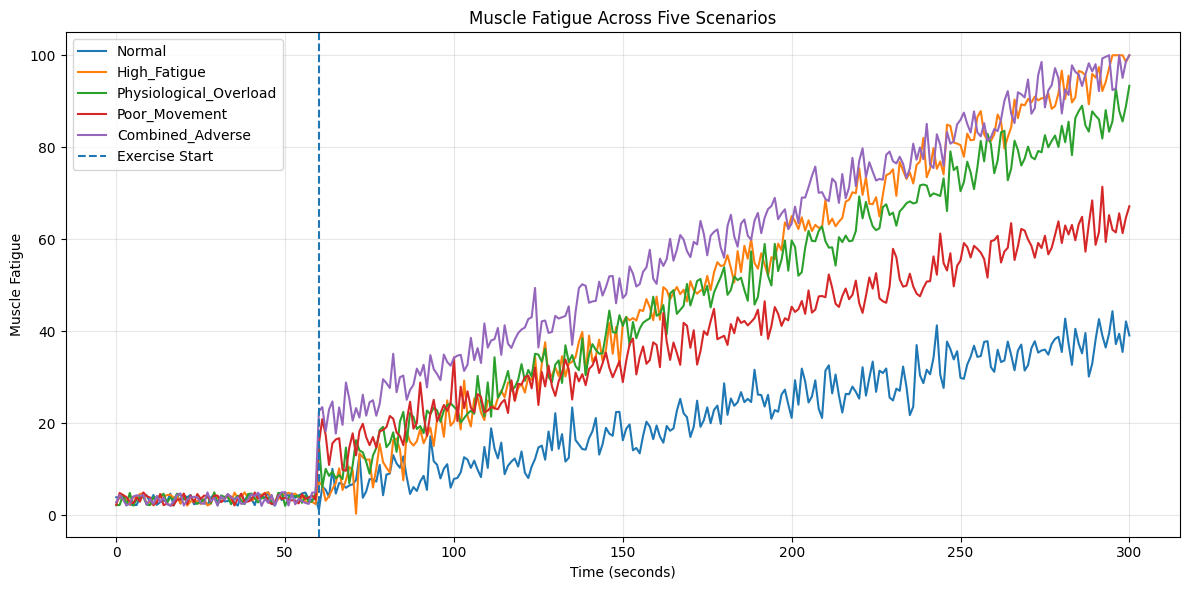

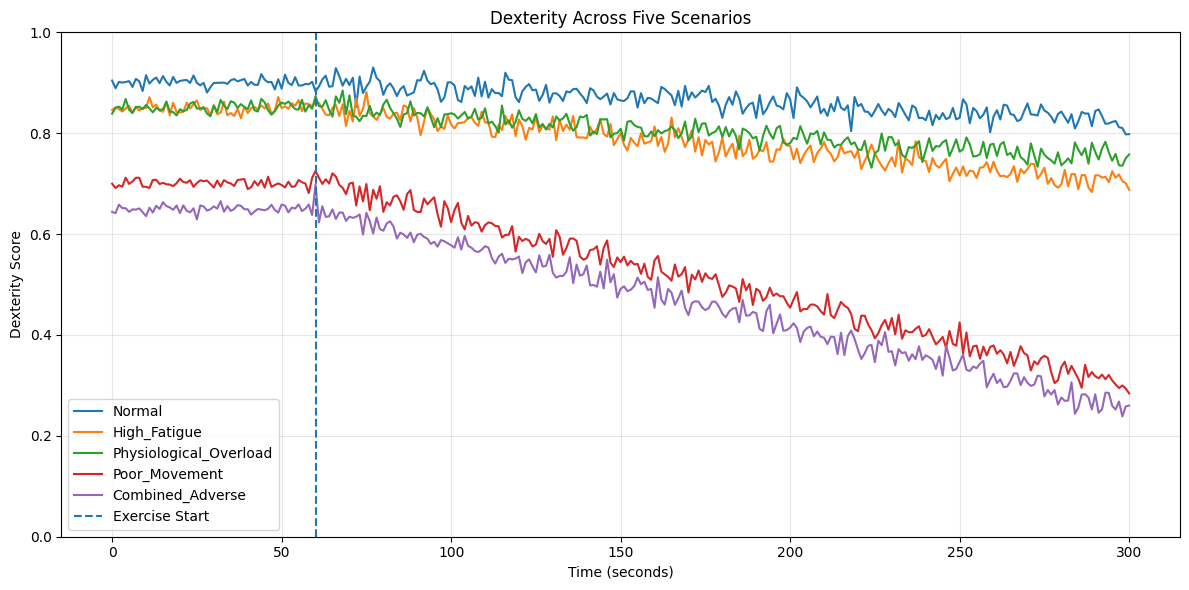

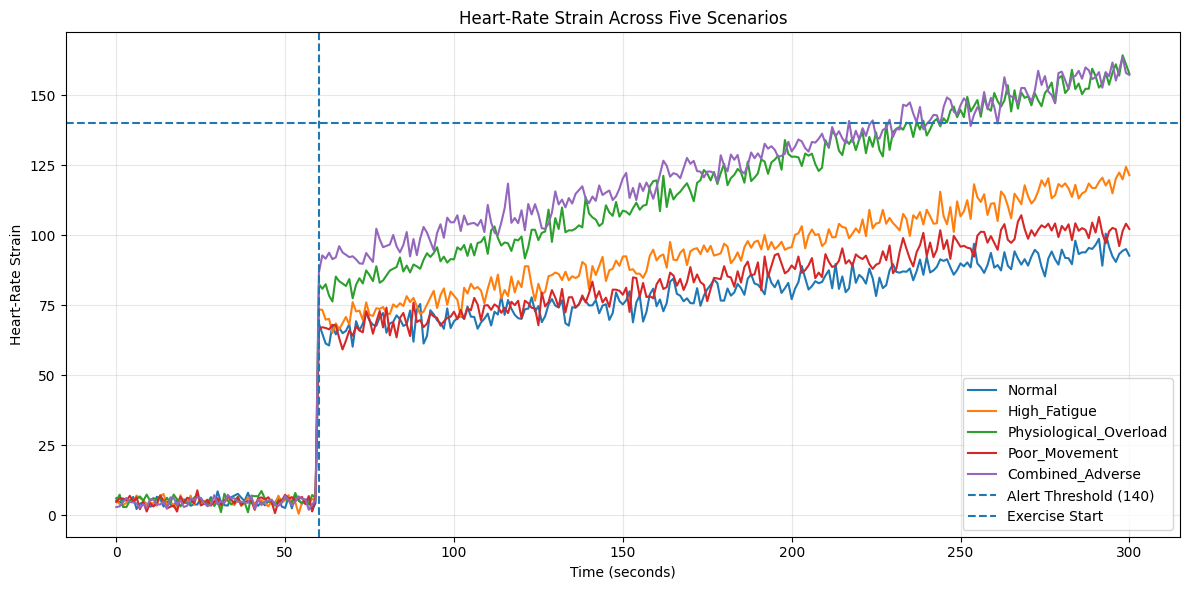

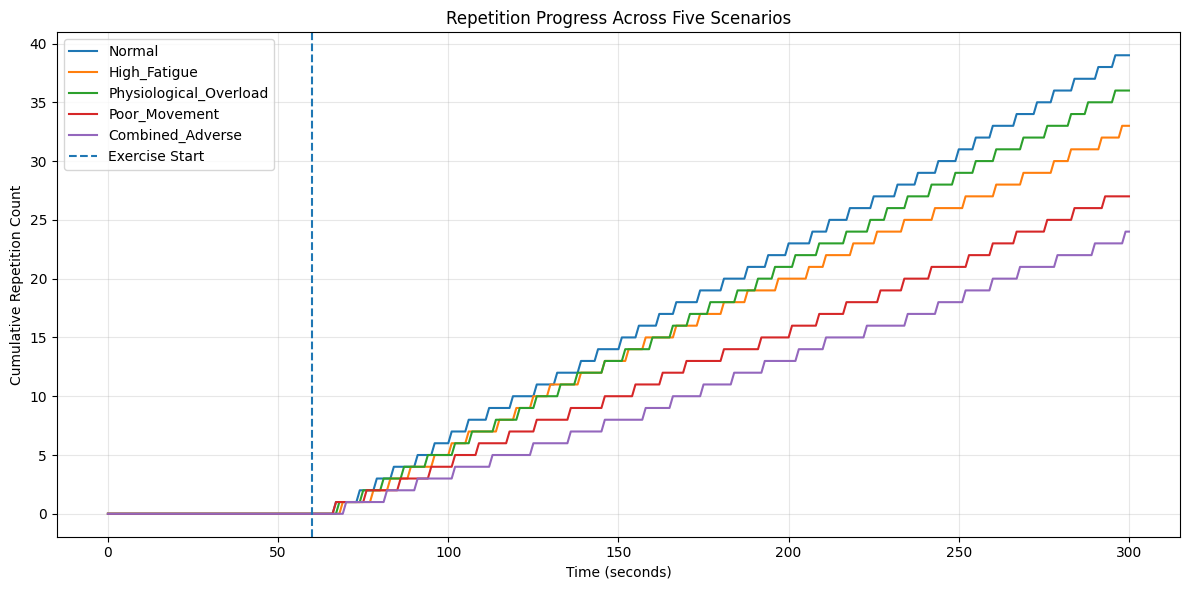


✅ FIVE-SCENARIO SIMULATION COMPLETED


In [ ]:
# ============================================================
# CELL 6: FIVE-SCENARIO SIMULATION COMPARISON
# Smart Rehabilitation Wristband
# ============================================================

# ------------------------------------------------------------
# Function: Generate one simulated session
# ------------------------------------------------------------

def generate_session(scenario, session_id=1):

    time = TIME_POINTS

    repetition_count = np.zeros(len(time))
    dexterity = np.zeros(len(time))
    fatigue = np.zeros(len(time))
    hr_strain = np.zeros(len(time))

    # ========================================================
    # 1. REPETITION GENERATION
    # ========================================================

    current_reps = 0

    # Different repetition speeds by scenario
    if scenario == "Normal":
        min_interval, max_interval = 5, 7

    elif scenario == "High_Fatigue":
        min_interval, max_interval = 5, 9

    elif scenario == "Physiological_Overload":
        min_interval, max_interval = 5, 8

    elif scenario == "Poor_Movement":
        min_interval, max_interval = 7, 11

    else:  # Combined_Adverse
        min_interval, max_interval = 8, 12

    next_rep_time = (
        WARMUP_SEC +
        np.random.randint(min_interval, max_interval + 1)
    )

    for i, t in enumerate(time):

        if t >= next_rep_time:

            current_reps += 1

            next_rep_time = (
                t +
                np.random.randint(
                    min_interval,
                    max_interval + 1
                )
            )

        repetition_count[i] = current_reps


    # ========================================================
    # 2. SCENARIO-SPECIFIC PARAMETERS
    # ========================================================

    if scenario == "Normal":

        dex_start = 0.90
        dex_end = 0.82

        fatigue_start = 5
        fatigue_end = 40

        hr_start = 65
        hr_end = 95


    elif scenario == "High_Fatigue":

        dex_start = 0.85
        dex_end = 0.70

        fatigue_start = 5
        fatigue_end = 100

        hr_start = 70
        hr_end = 120


    elif scenario == "Physiological_Overload":

        dex_start = 0.85
        dex_end = 0.75

        fatigue_start = 10
        fatigue_end = 90

        hr_start = 80
        hr_end = 160


    elif scenario == "Poor_Movement":

        dex_start = 0.70
        dex_end = 0.30

        fatigue_start = 15
        fatigue_end = 65

        hr_start = 65
        hr_end = 105


    else:  # Combined_Adverse

        dex_start = 0.65
        dex_end = 0.25

        fatigue_start = 20
        fatigue_end = 100

        hr_start = 90
        hr_end = 160


    # ========================================================
    # 3. GENERATE TIME-VARYING SIGNALS
    # ========================================================

    for i, t in enumerate(time):

        if t < WARMUP_SEC:

            # ----------------------------
            # Warm-up
            # ----------------------------

            dexterity[i] = (
                dex_start +
                np.random.normal(0, 0.008)
            )

            fatigue[i] = np.random.uniform(
                2, 5
            )

            hr_strain[i] = np.random.normal(
                5, 1.5
            )

        else:

            # Exercise progress: 0 → 1
            progress = (
                (t - WARMUP_SEC) /
                (SESSION_DURATION_SEC - WARMUP_SEC)
            )

            # ----------------------------
            # Dexterity
            # ----------------------------

            base_dexterity = (
                dex_start +
                (dex_end - dex_start) * progress
            )

            dexterity[i] = (
                base_dexterity +
                np.random.normal(0, 0.015)
            )

            # ----------------------------
            # Fatigue
            # ----------------------------

            base_fatigue = (
                fatigue_start +
                (fatigue_end - fatigue_start) * progress
            )

            fatigue[i] = (
                base_fatigue +
                np.random.normal(0, 3)
            )

            # ----------------------------
            # Heart-rate strain
            # ----------------------------

            base_hr = (
                hr_start +
                (hr_end - hr_start) * progress
            )

            hr_strain[i] = (
                base_hr +
                np.random.normal(0, 3)
            )


    # ========================================================
    # 4. LIMIT VALUES
    # ========================================================

    dexterity = np.clip(
        dexterity,
        0,
        1
    )

    fatigue = np.clip(
        fatigue,
        0,
        100
    )

    hr_strain = np.clip(
        hr_strain,
        0,
        None
    )


    # ========================================================
    # 5. CREATE DATAFRAME
    # ========================================================

    session = pd.DataFrame({

        "session_id": session_id,

        "time_sec": time,

        "scenario": scenario,

        "repetitionCount":
            repetition_count.astype(int),

        "dexterityScore":
            dexterity,

        "muscleFatigue":
            fatigue,

        "heartRateStrain":
            hr_strain
    })

    return session


# ============================================================
# GENERATE FIVE SCENARIOS
# ============================================================

scenario_sessions = {}

for scenario in SCENARIOS:

    scenario_sessions[scenario] = generate_session(
        scenario=scenario,
        session_id=1
    )


# ============================================================
# SUMMARY TABLE
# ============================================================

summary_rows = []

for scenario, data in scenario_sessions.items():

    summary_rows.append({

        "Scenario": scenario,

        "Final_Repetitions":
            data["repetitionCount"].iloc[-1],

        "Mean_Dexterity":
            data["dexterityScore"].mean(),

        "Final_Dexterity":
            data["dexterityScore"].iloc[-1],

        "Final_Fatigue":
            data["muscleFatigue"].iloc[-1],

        "Final_HR_Strain":
            data["heartRateStrain"].iloc[-1],

        "Max_HR_Strain":
            data["heartRateStrain"].max()
    })


scenario_summary = pd.DataFrame(summary_rows)


# ============================================================
# PRINT RESULTS
# ============================================================

print("=" * 70)
print("FIVE-SCENARIO SIMULATION COMPARISON")
print("=" * 70)

display(scenario_summary.round(3))


# ============================================================
# FINAL VALUES
# ============================================================

print("\nFinal values for each scenario:")
print("-" * 70)

for scenario, data in scenario_sessions.items():

    print(
        f"{scenario:25s} | "
        f"R={data['repetitionCount'].iloc[-1]:3.0f} | "
        f"D={data['dexterityScore'].iloc[-1]:.3f} | "
        f"F={data['muscleFatigue'].iloc[-1]:6.2f} | "
        f"H={data['heartRateStrain'].iloc[-1]:6.2f}"
    )


# ============================================================
# VISUALIZATION 1: FATIGUE
# ============================================================

plt.figure(figsize=(12, 6))

for scenario, data in scenario_sessions.items():

    plt.plot(
        data["time_sec"],
        data["muscleFatigue"],
        label=scenario
    )

plt.axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Muscle Fatigue")
plt.title("Muscle Fatigue Across Five Scenarios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 2: DEXTERITY
# ============================================================

plt.figure(figsize=(12, 6))

for scenario, data in scenario_sessions.items():

    plt.plot(
        data["time_sec"],
        data["dexterityScore"],
        label=scenario
    )

plt.axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Dexterity Score")
plt.title("Dexterity Across Five Scenarios")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 3: HEART-RATE STRAIN
# ============================================================

plt.figure(figsize=(12, 6))

for scenario, data in scenario_sessions.items():

    plt.plot(
        data["time_sec"],
        data["heartRateStrain"],
        label=scenario
    )

plt.axhline(
    HR_STRAIN_THRESHOLD,
    linestyle="--",
    label=f"Alert Threshold ({HR_STRAIN_THRESHOLD})"
)

plt.axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Heart-Rate Strain")
plt.title("Heart-Rate Strain Across Five Scenarios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 4: REPETITIONS
# ============================================================

plt.figure(figsize=(12, 6))

for scenario, data in scenario_sessions.items():

    plt.plot(
        data["time_sec"],
        data["repetitionCount"],
        label=scenario
    )

plt.axvline(
    WARMUP_SEC,
    linestyle="--",
    label="Exercise Start"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Cumulative Repetition Count")
plt.title("Repetition Progress Across Five Scenarios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("✅ FIVE-SCENARIO SIMULATION COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# CELL 7: GENERATE FULL SYNTHETIC REHABILITATION DATASET
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

N_SESSIONS_PER_SCENARIO = 200

SCENARIOS = [
    "Normal",
    "High_Fatigue",
    "Physiological_Overload",
    "Poor_Movement",
    "Combined_Adverse"
]

TOTAL_SESSIONS = N_SESSIONS_PER_SCENARIO * len(SCENARIOS)

print("=" * 70)
print("FULL SYNTHETIC REHABILITATION DATASET GENERATION")
print("=" * 70)

print(f"\nSessions per scenario : {N_SESSIONS_PER_SCENARIO}")
print(f"Number of scenarios  : {len(SCENARIOS)}")
print(f"Total sessions        : {TOTAL_SESSIONS}")
print(f"Time points/session   : {len(TIME_POINTS)}")
print(f"Total observations    : {TOTAL_SESSIONS * len(TIME_POINTS):,}")


# ------------------------------------------------------------
# Generate sessions
# ------------------------------------------------------------

all_sessions = []

session_counter = 1

for scenario in SCENARIOS:

    print(f"\nGenerating {scenario} sessions...")

    for local_id in range(N_SESSIONS_PER_SCENARIO):

        # Generate one session using our validated simulator
        session_df = generate_session(
            scenario=scenario,
            session_id=session_counter
        )

        # ----------------------------------------------------
        # Enforce warm-up conditions
        # ----------------------------------------------------

        warmup_mask = session_df["time_sec"] < WARMUP_SEC

        session_df.loc[warmup_mask, "repetitionCount"] = 0
        session_df.loc[warmup_mask, "muscleFatigue"] = 0.0
        session_df.loc[warmup_mask, "heartRateStrain"] = 0.0

        # ----------------------------------------------------
        # Keep dexterity within the scenario-defined range
        # ----------------------------------------------------

        d_low, d_high = SCENARIO_CONFIG[scenario]["dexterity_range"]

        session_df["dexterityScore"] = session_df[
            "dexterityScore"
        ].clip(d_low, d_high)

        # ----------------------------------------------------
        # Independent ground truth
        #
        # IMPORTANT:
        # Ground truth is NOT calculated from Q or Alert.
        # It is defined from the simulation scenario.
        # ----------------------------------------------------

        if scenario == "Normal":
            session_df["groundTruth"] = "No_Adverse"
        else:
            session_df["groundTruth"] = "Adverse"

        all_sessions.append(session_df)

        session_counter += 1


# ------------------------------------------------------------
# Combine all sessions
# ------------------------------------------------------------

full_dataset = pd.concat(
    all_sessions,
    ignore_index=True
)


# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------

full_dataset = full_dataset[
    [
        "session_id",
        "time_sec",
        "scenario",
        "repetitionCount",
        "dexterityScore",
        "muscleFatigue",
        "heartRateStrain",
        "groundTruth"
    ]
]


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET GENERATED SUCCESSFULLY")
print("=" * 70)

print("\nShape:", full_dataset.shape)

print("\nScenario distribution:")
display(
    full_dataset["scenario"].value_counts().sort_index()
)

print("\nGround-truth distribution:")
display(
    full_dataset["groundTruth"].value_counts()
)

print("\nFirst 10 rows:")
display(
    full_dataset.head(10)
)

print("\nLast 10 rows:")
display(
    full_dataset.tail(10)
)


# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\nMissing values:")
display(
    full_dataset.isnull().sum()
)


# ------------------------------------------------------------
# Check duplicate rows
# ------------------------------------------------------------

duplicate_count = full_dataset.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_count}")


# ------------------------------------------------------------
# Warm-up validation
# ------------------------------------------------------------

warmup_data = full_dataset[
    full_dataset["time_sec"] < WARMUP_SEC
]

print("\nWarm-up validation:")
print(
    "Maximum repetition count:",
    warmup_data["repetitionCount"].max()
)

print(
    "Maximum muscle fatigue:",
    warmup_data["muscleFatigue"].max()
)

print(
    "Maximum HR strain:",
    warmup_data["heartRateStrain"].max()
)


# ------------------------------------------------------------
# Final feature summary
# ------------------------------------------------------------

print("\nFeature summary:")
display(
    full_dataset[
        [
            "repetitionCount",
            "dexterityScore",
            "muscleFatigue",
            "heartRateStrain"
        ]
    ].describe()
)

print("\n✅ FULL SYNTHETIC DATASET CREATED!")

FULL SYNTHETIC REHABILITATION DATASET GENERATION

Sessions per scenario : 200
Number of scenarios  : 5
Total sessions        : 1000
Time points/session   : 301
Total observations    : 301,000

Generating Normal sessions...

Generating High_Fatigue sessions...

Generating Physiological_Overload sessions...

Generating Poor_Movement sessions...

Generating Combined_Adverse sessions...

DATASET GENERATED SUCCESSFULLY

Shape: (301000, 8)

Scenario distribution:


,count
scenario,
Combined_Adverse,60200
High_Fatigue,60200
Normal,60200
Physiological_Overload,60200
Poor_Movement,60200



Ground-truth distribution:


,count
groundTruth,
Adverse,240800
No_Adverse,60200



First 10 rows:


...


Missing values:


,0
session_id,0
time_sec,0
scenario,0
repetitionCount,0
dexterityScore,0
muscleFatigue,0
heartRateStrain,0
groundTruth,0



Duplicate rows: 0

Warm-up validation:
Maximum repetition count: 0
Maximum muscle fatigue: 0.0
Maximum HR strain: 0.0

Feature summary:


,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain
count,301000.000000,301000.000000,301000.000000,301000.000000
mean,12.613017,0.690688,36.022781,80.870113
std,10.970383,0.180083,28.410071,46.066942
min,0.000000,0.208624,0.000000,0.000000
25%,1.000000,0.587602,12.058325,69.918765
50%,11.000000,0.766701,32.625964,88.720545
75%,21.000000,0.842008,57.094116,109.604217
max,42.000000,0.950000,100.000000,169.349005



✅ FULL SYNTHETIC DATASET CREATED!


In [ ]:
# ============================================================
# CELL 8: SAVE AND DOWNLOAD FULL SYNTHETIC DATASET
# ============================================================

OUTPUT_FILE = "smart_rehab_full_synthetic_dataset.csv"

# Save dataset as CSV
full_dataset.to_csv(
    OUTPUT_FILE,
    index=False
)

print("=" * 70)
print("DATASET SAVED SUCCESSFULLY")
print("=" * 70)

print(f"\nFile name : {OUTPUT_FILE}")
print(f"Rows      : {len(full_dataset):,}")
print(f"Columns   : {len(full_dataset.columns)}")

# Download to your PC
from google.colab import files

files.download(OUTPUT_FILE)

DATASET SAVED SUCCESSFULLY

File name : smart_rehab_full_synthetic_dataset.csv
Rows      : 301,000
Columns   : 8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 9: CALCULATE READINESS SCORE
# ============================================================

print("=" * 70)
print("READINESS SCORE CALCULATION")
print("=" * 70)

# ------------------------------------------------------------
# Existing readiness-score formula
#
# Q = (R × D) / (F + H + 0.5)
# ------------------------------------------------------------

full_dataset["readinessScore"] = (
    full_dataset["repetitionCount"]
    * full_dataset["dexterityScore"]
) / (
    full_dataset["muscleFatigue"]
    + full_dataset["heartRateStrain"]
    + 0.5
)

# ------------------------------------------------------------
# Check readiness score statistics
# ------------------------------------------------------------

print("\nReadiness Score Summary:")
display(
    full_dataset["readinessScore"].describe()
)

# ------------------------------------------------------------
# Check readiness score by scenario
# ------------------------------------------------------------

print("\nReadiness Score by Scenario:")

scenario_q_summary = (
    full_dataset
    .groupby("scenario")["readinessScore"]
    .agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
    .round(4)
)

display(scenario_q_summary)

# ------------------------------------------------------------
# Existing threshold from the paper
# ------------------------------------------------------------

READINESS_THRESHOLD = 0.6

full_dataset["belowReadinessThreshold"] = (
    full_dataset["readinessScore"] < READINESS_THRESHOLD
)

# ------------------------------------------------------------
# Count observations below threshold
# ------------------------------------------------------------

print(
    f"\nReadiness threshold: Q < {READINESS_THRESHOLD}"
)

print(
    "Observations below threshold:",
    full_dataset["belowReadinessThreshold"].sum()
)

print(
    "Observations at/above threshold:",
    (~full_dataset["belowReadinessThreshold"]).sum()
)

# ------------------------------------------------------------
# Percentage below threshold
# ------------------------------------------------------------

below_pct = (
    full_dataset["belowReadinessThreshold"].mean() * 100
)

print(
    f"Percentage below threshold: {below_pct:.2f}%"
)

# ------------------------------------------------------------
# Show examples
# ------------------------------------------------------------

print("\nExample rows with Readiness Score:")

display(
    full_dataset[
        [
            "session_id",
            "time_sec",
            "scenario",
            "repetitionCount",
            "dexterityScore",
            "muscleFatigue",
            "heartRateStrain",
            "readinessScore",
            "belowReadinessThreshold",
            "groundTruth"
        ]
    ].head(20)
)

print("\n" + "=" * 70)
print("✅ READINESS SCORE CALCULATED")
print("=" * 70)

READINESS SCORE CALCULATION

Readiness Score Summary:


,readinessScore
count,301000.000000
mean,0.058377
std,0.058860
min,0.000000
25%,0.010150
50%,0.045232
75%,0.092688
max,0.283408



Readiness Score by Scenario:


,count,mean,std,min,median,max
scenario,,,,,,
Combined_Adverse,60200,0.0179,0.0114,0.0,0.0236,0.0354
High_Fatigue,60200,0.0615,0.0410,0.0,0.0757,0.1285
Normal,60200,0.1193,0.0860,0.0,0.1339,0.2834
Physiological_Overload,60200,0.0600,0.0407,0.0,0.0720,0.1233
Poor_Movement,60200,0.0332,0.0216,0.0,0.0443,0.0696



Readiness threshold: Q < 0.6
Observations below threshold: 301000
Observations at/above threshold: 0
Percentage below threshold: 100.00%

Example rows with Readiness Score:


,session_id,time_sec,scenario,repetitionCount,dexterityScore,muscleFatigue,heartRateStrain,readinessScore,belowReadinessThreshold,groundTruth
0,1,0,Normal,0,0.900158,0.0,0.0,0.0,True,No_Adverse
1,1,1,Normal,0,0.890596,0.0,0.0,0.0,True,No_Adverse
2,1,2,Normal,0,0.898047,0.0,0.0,0.0,True,No_Adverse
3,1,3,Normal,0,0.905023,0.0,0.0,0.0,True,No_Adverse
4,1,4,Normal,0,0.895246,0.0,0.0,0.0,True,No_Adverse
5,1,5,Normal,0,0.902737,0.0,0.0,0.0,True,No_Adverse
6,1,6,Normal,0,0.894165,0.0,0.0,0.0,True,No_Adverse
7,1,7,Normal,0,0.899444,0.0,0.0,0.0,True,No_Adverse
8,1,8,Normal,0,0.896896,0.0,0.0,0.0,True,No_Adverse
9,1,9,Normal,0,0.901192,0.0,0.0,0.0,True,No_Adverse



✅ READINESS SCORE CALCULATED


THRESHOLD SENSITIVITY ANALYSIS

Total observations: 301000
Active observations (R > 0): 233272
Warm-up / inactive observations excluded: 67728

Overall Threshold Sensitivity:


,threshold,below_count,total_active,below_percentage
0,0.02,20585,233272,8.82
1,0.04,74854,233272,32.09
2,0.06,121316,233272,52.01
3,0.08,140276,233272,60.13
4,0.10,172763,233272,74.06
5,0.15,206324,233272,88.45
6,0.20,218656,233272,93.73
7,0.25,232827,233272,99.81
8,0.30,233272,233272,100.00



Scenario-wise Threshold Sensitivity:


scenario,Combined_Adverse,High_Fatigue,Normal,Physiological_Overload,Poor_Movement
threshold,,,,,
0.02,20.94,4.85,2.56,5.64,10.34
0.04,100.00,12.50,7.61,14.21,27.09
0.06,100.00,23.54,12.50,26.10,99.13
0.08,100.00,40.15,18.00,43.59,100.00
0.10,100.00,72.82,24.04,74.20,100.00
0.15,100.00,100.00,42.65,100.00,100.00
0.20,100.00,100.00,68.89,100.00,100.00
0.25,100.00,100.00,99.05,100.00,100.00
0.30,100.00,100.00,100.00,100.00,100.00


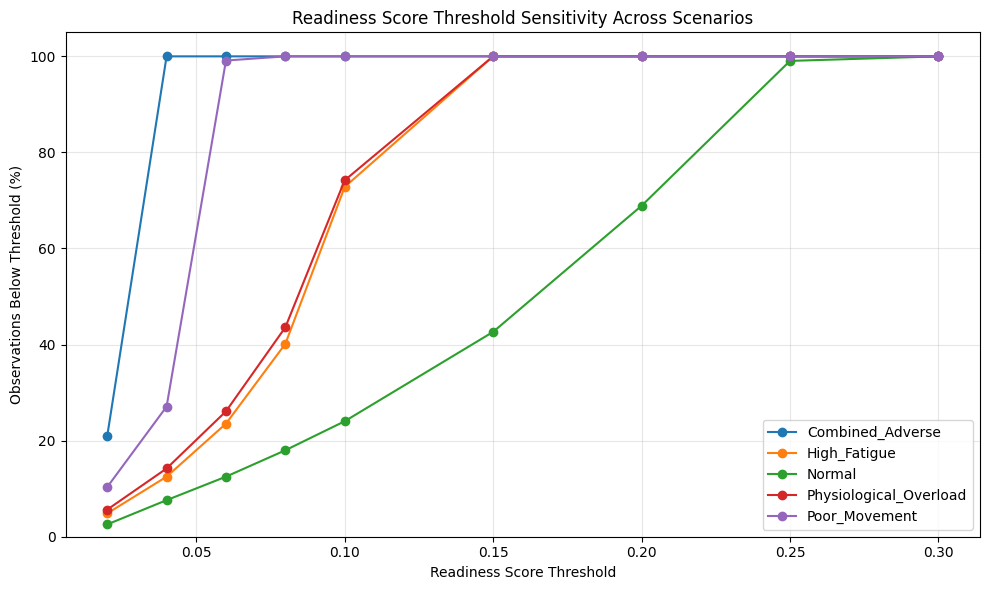


Observed Readiness Score Range:
Minimum Q = 0.0044
Maximum Q = 0.2834

Original threshold:
Q < 0.60
Result: The original threshold is above the maximum observed active-session Q.

✅ THRESHOLD SENSITIVITY ANALYSIS COMPLETED


In [ ]:
# ============================================================
# CELL 10: THRESHOLD SENSITIVITY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Consider only active rehabilitation observations
#    (R > 0), consistent with the alert condition CB.
# ------------------------------------------------------------

active_data = full_dataset[
    full_dataset["repetitionCount"] > 0
].copy()

print("\nTotal observations:", len(full_dataset))
print("Active observations (R > 0):", len(active_data))
print("Warm-up / inactive observations excluded:",
      len(full_dataset) - len(active_data))


# ------------------------------------------------------------
# 2. Define a range of candidate readiness thresholds
# ------------------------------------------------------------

thresholds = [
    0.02,
    0.04,
    0.06,
    0.08,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30
]


# ------------------------------------------------------------
# 3. Calculate percentage of active observations below
#    each threshold
# ------------------------------------------------------------

overall_results = []

for threshold in thresholds:

    below_count = (
        active_data["readinessScore"] < threshold
    ).sum()

    total_count = len(active_data)

    below_percentage = (
        below_count / total_count
    ) * 100

    overall_results.append({
        "threshold": threshold,
        "below_count": below_count,
        "total_active": total_count,
        "below_percentage": below_percentage
    })

threshold_summary = pd.DataFrame(overall_results)

print("\nOverall Threshold Sensitivity:")
display(
    threshold_summary.round(2)
)


# ------------------------------------------------------------
# 4. Scenario-wise threshold sensitivity
# ------------------------------------------------------------

scenario_results = []

for threshold in thresholds:

    for scenario in sorted(active_data["scenario"].unique()):

        scenario_data = active_data[
            active_data["scenario"] == scenario
        ]

        below_count = (
            scenario_data["readinessScore"] < threshold
        ).sum()

        total_count = len(scenario_data)

        below_percentage = (
            below_count / total_count
        ) * 100

        scenario_results.append({
            "threshold": threshold,
            "scenario": scenario,
            "below_percentage": below_percentage
        })

scenario_threshold_summary = pd.DataFrame(
    scenario_results
)

print("\nScenario-wise Threshold Sensitivity:")
display(
    scenario_threshold_summary
    .pivot(
        index="threshold",
        columns="scenario",
        values="below_percentage"
    )
    .round(2)
)


# ------------------------------------------------------------
# 5. Plot threshold sensitivity
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for scenario in sorted(active_data["scenario"].unique()):

    scenario_plot = scenario_threshold_summary[
        scenario_threshold_summary["scenario"] == scenario
    ]

    plt.plot(
        scenario_plot["threshold"],
        scenario_plot["below_percentage"],
        marker="o",
        label=scenario
    )

plt.xlabel("Readiness Score Threshold")
plt.ylabel("Observations Below Threshold (%)")
plt.title("Readiness Score Threshold Sensitivity Across Scenarios")
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 6. Identify threshold values where the original 0.6
#    threshold becomes relevant relative to observed range
# ------------------------------------------------------------

print("\nObserved Readiness Score Range:")
print(
    f"Minimum Q = {active_data['readinessScore'].min():.4f}"
)
print(
    f"Maximum Q = {active_data['readinessScore'].max():.4f}"
)

print("\nOriginal threshold:")
print("Q < 0.60")

if active_data["readinessScore"].max() < 0.60:
    print(
        "Result: The original threshold is above the "
        "maximum observed active-session Q."
    )

print("\n" + "=" * 70)
print("✅ THRESHOLD SENSITIVITY ANALYSIS COMPLETED")
print("=" * 70)

DUAL-CONDITION ALERT LOGIC ANALYSIS

Overall Condition Activation:
--------------------------------------------------
Condition A         :   33644 observations ( 11.18%)
Condition B         :  233272 observations ( 77.50%)
Combined Alert      :  233272 observations ( 77.50%)

Scenario-wise Alert Behaviour:


,total_observations,condition_A_count,condition_B_count,alert_count,condition_A_pct,condition_B_pct,alert_pct
scenario,,,,,,,
Combined_Adverse,60200,13836,46202,46202,22.98,76.75,76.75
High_Fatigue,60200,7697,46808,46808,12.79,77.75,77.75
Normal,60200,0,46987,46987,0.00,78.05,78.05
Physiological_Overload,60200,12111,46888,46888,20.12,77.89,77.89
Poor_Movement,60200,0,46387,46387,0.00,77.05,77.05



Condition Overlap:


,case,count,percentage
0,Condition A only,0,0.00
1,Condition B only,199628,66.32
2,Both A and B,33644,11.18
3,Neither condition,67728,22.50



Alert Behaviour by Ground Truth:


,total,condition_A,condition_B,alert,alert_percentage
groundTruth,,,,,
Adverse,240800,33644,186285,186285,77.36
No_Adverse,60200,0,46987,46987,78.05


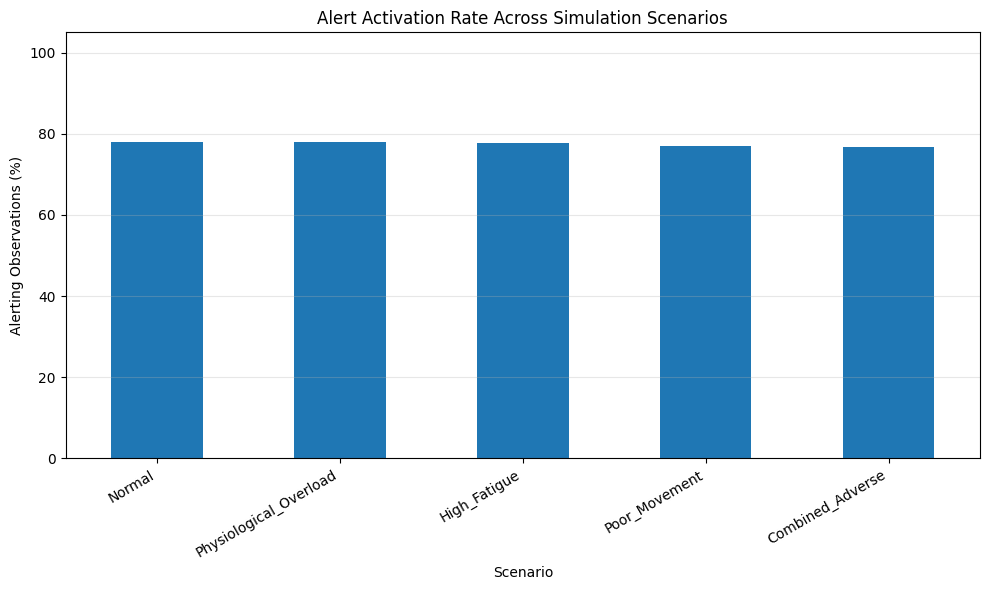


Key Diagnostic:
--------------------------------------------------

✅ DUAL-CONDITION ALERT LOGIC ANALYSIS COMPLETED


In [ ]:
# ============================================================
# CELL 11: DUAL-CONDITION ALERT LOGIC
# ============================================================

print("=" * 70)
print("DUAL-CONDITION ALERT LOGIC ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Original Condition A
#    Physiological condition
# ------------------------------------------------------------

full_dataset["condition_A"] = (
    (full_dataset["muscleFatigue"] > 85) |
    (full_dataset["heartRateStrain"] > 140)
)


# ------------------------------------------------------------
# 2. Original Condition B
#    Low readiness during active rehabilitation
# ------------------------------------------------------------

full_dataset["condition_B"] = (
    (full_dataset["repetitionCount"] > 0) &
    (full_dataset["readinessScore"] < 0.60)
)


# ------------------------------------------------------------
# 3. Combined Alert
# ------------------------------------------------------------

full_dataset["alert"] = (
    full_dataset["condition_A"] |
    full_dataset["condition_B"]
)


# ------------------------------------------------------------
# 4. Overall condition activation
# ------------------------------------------------------------

total = len(full_dataset)

print("\nOverall Condition Activation:")
print("-" * 50)

for name, column in [
    ("Condition A", "condition_A"),
    ("Condition B", "condition_B"),
    ("Combined Alert", "alert")
]:

    count = full_dataset[column].sum()
    percentage = (count / total) * 100

    print(
        f"{name:20s}: "
        f"{count:7d} observations "
        f"({percentage:6.2f}%)"
    )


# ------------------------------------------------------------
# 5. Scenario-wise alert behaviour
# ------------------------------------------------------------

scenario_alert = (
    full_dataset
    .groupby("scenario")
    .agg(
        total_observations=("alert", "size"),
        condition_A_count=("condition_A", "sum"),
        condition_B_count=("condition_B", "sum"),
        alert_count=("alert", "sum")
    )
)

scenario_alert["condition_A_pct"] = (
    scenario_alert["condition_A_count"]
    / scenario_alert["total_observations"]
) * 100

scenario_alert["condition_B_pct"] = (
    scenario_alert["condition_B_count"]
    / scenario_alert["total_observations"]
) * 100

scenario_alert["alert_pct"] = (
    scenario_alert["alert_count"]
    / scenario_alert["total_observations"]
) * 100

scenario_alert = scenario_alert.round(2)

print("\nScenario-wise Alert Behaviour:")
display(scenario_alert)


# ------------------------------------------------------------
# 6. Condition overlap analysis
# ------------------------------------------------------------

both_conditions = (
    full_dataset["condition_A"] &
    full_dataset["condition_B"]
)

A_only = (
    full_dataset["condition_A"] &
    ~full_dataset["condition_B"]
)

B_only = (
    full_dataset["condition_B"] &
    ~full_dataset["condition_A"]
)

neither = (
    ~full_dataset["condition_A"] &
    ~full_dataset["condition_B"]
)

overlap_summary = pd.DataFrame({
    "case": [
        "Condition A only",
        "Condition B only",
        "Both A and B",
        "Neither condition"
    ],
    "count": [
        A_only.sum(),
        B_only.sum(),
        both_conditions.sum(),
        neither.sum()
    ]
})

overlap_summary["percentage"] = (
    overlap_summary["count"] / total
) * 100

print("\nCondition Overlap:")
display(overlap_summary.round(2))


# ------------------------------------------------------------
# 7. Alert behaviour by ground truth
# ------------------------------------------------------------

ground_truth_alert = (
    full_dataset
    .groupby("groundTruth")
    .agg(
        total=("alert", "size"),
        condition_A=("condition_A", "sum"),
        condition_B=("condition_B", "sum"),
        alert=("alert", "sum")
    )
)

ground_truth_alert["alert_percentage"] = (
    ground_truth_alert["alert"]
    / ground_truth_alert["total"]
) * 100

print("\nAlert Behaviour by Ground Truth:")
display(ground_truth_alert.round(2))


# ------------------------------------------------------------
# 8. Alert rate by scenario plot
# ------------------------------------------------------------

plot_data = (
    scenario_alert["alert_pct"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plot_data.plot(
    kind="bar"
)

plt.xlabel("Scenario")
plt.ylabel("Alerting Observations (%)")
plt.title("Alert Activation Rate Across Simulation Scenarios")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 9. Print key diagnostic
# ------------------------------------------------------------

print("\nKey Diagnostic:")
print("-" * 50)

if full_dataset["condition_B"].mean() > 0.95:
    print(
        "⚠ Condition B is activated in more than 95% "
        "of observations."
    )
    print(
        "This is expected from the current Q < 0.60 "
        "threshold because Q never reaches 0.60."
    )
    print(
        "The original threshold should therefore be "
        "treated as a baseline parameter, not as a validated threshold."
    )

print("\n" + "=" * 70)
print("✅ DUAL-CONDITION ALERT LOGIC ANALYSIS COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# STEP 9 — NOISE ROBUSTNESS ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("NOISE ROBUSTNESS ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Noise levels
# ------------------------------------------------------------
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.15, 0.20]

noise_results = []

# Use the existing full dataset
base_df = full_dataset.copy()

for noise_level in NOISE_LEVELS:

    df_noise = base_df.copy()

    # Reproducible noise
    rng = np.random.default_rng(RANDOM_SEED)

    # Add Gaussian measurement noise
    df_noise["dexterity_noisy"] = (
        df_noise["dexterityScore"]
        + rng.normal(0, noise_level, len(df_noise))
    ).clip(0, 1)

    df_noise["fatigue_noisy"] = (
        df_noise["muscleFatigue"]
        + rng.normal(0, noise_level * 100, len(df_noise))
    ).clip(0, 100)

    df_noise["hr_noisy"] = (
        df_noise["heartRateStrain"]
        + rng.normal(0, noise_level * 100, len(df_noise))
    ).clip(0, 200)

    # Recalculate readiness score using noisy measurements
    df_noise["Q_noisy"] = (
        df_noise["repetitionCount"] * df_noise["dexterity_noisy"]
    ) / (
        df_noise["fatigue_noisy"]
        + df_noise["hr_noisy"]
        + 0.5
    )

    # Alert conditions
    condition_A = (
        (df_noise["fatigue_noisy"] > FATIGUE_THRESHOLD)
        |
        (df_noise["hr_noisy"] > HR_STRAIN_THRESHOLD)
    )

    condition_B = (
        (df_noise["repetitionCount"] > 0)
        &
        (df_noise["Q_noisy"] < READINESS_THRESHOLD)
    )

    alert = condition_A | condition_B

    # Overall metrics
    noise_results.append({
        "noise_level": noise_level,
        "mean_Q": df_noise["Q_noisy"].mean(),
        "std_Q": df_noise["Q_noisy"].std(),
        "condition_A_pct": condition_A.mean() * 100,
        "condition_B_pct": condition_B.mean() * 100,
        "alert_pct": alert.mean() * 100
    })

noise_results_df = pd.DataFrame(noise_results)

print("\nNoise Robustness Results:")
print("-" * 70)
print(noise_results_df.round(4).to_string(index=False))

print("\n" + "=" * 70)
print("NOISE ROBUSTNESS ANALYSIS COMPLETED")
print("=" * 70)

NOISE ROBUSTNESS ANALYSIS


NameError: name 'full_dataset' is not defined

In [ ]:
# Check available CSV files in Colab
import os

print("CSV files available:")
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

CSV files available:
/content/smart_rehab_full_synthetic_dataset.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv


In [ ]:
# ============================================================
# STEP 9 — NOISE ROBUSTNESS ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("NOISE ROBUSTNESS ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Load the saved synthetic dataset
# ------------------------------------------------------------
DATASET_PATH = "/content/smart_rehab_full_synthetic_dataset.csv"

base_df = pd.read_csv(DATASET_PATH)

print(f"\nDataset loaded successfully.")
print(f"Rows: {len(base_df):,}")
print(f"Columns: {len(base_df.columns)}")

# ------------------------------------------------------------
# Noise levels
# ------------------------------------------------------------
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.15, 0.20]

noise_results = []

for noise_level in NOISE_LEVELS:

    df_noise = base_df.copy()

    # Reproducible noise
    rng = np.random.default_rng(RANDOM_SEED)

    # Dexterity noise
    df_noise["dexterity_noisy"] = (
        df_noise["dexterityScore"]
        + rng.normal(0, noise_level, len(df_noise))
    ).clip(0, 1)

    # Fatigue noise
    df_noise["fatigue_noisy"] = (
        df_noise["muscleFatigue"]
        + rng.normal(0, noise_level * 100, len(df_noise))
    ).clip(0, 100)

    # Heart-rate strain noise
    df_noise["hr_noisy"] = (
        df_noise["heartRateStrain"]
        + rng.normal(0, noise_level * 100, len(df_noise))
    ).clip(0, 200)

    # --------------------------------------------------------
    # Recalculate readiness score
    # --------------------------------------------------------
    df_noise["Q_noisy"] = (
        df_noise["repetitionCount"] * df_noise["dexterity_noisy"]
    ) / (
        df_noise["fatigue_noisy"]
        + df_noise["hr_noisy"]
        + 0.5
    )

    # --------------------------------------------------------
    # Alert conditions
    # --------------------------------------------------------
    condition_A = (
        (df_noise["fatigue_noisy"] > FATIGUE_THRESHOLD)
        |
        (df_noise["hr_noisy"] > HR_STRAIN_THRESHOLD)
    )

    condition_B = (
        (df_noise["repetitionCount"] > 0)
        &
        (df_noise["Q_noisy"] < READINESS_THRESHOLD)
    )

    alert = condition_A | condition_B

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    noise_results.append({
        "noise_level": noise_level,
        "mean_Q": df_noise["Q_noisy"].mean(),
        "std_Q": df_noise["Q_noisy"].std(),
        "condition_A_pct": condition_A.mean() * 100,
        "condition_B_pct": condition_B.mean() * 100,
        "alert_pct": alert.mean() * 100
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
noise_results_df = pd.DataFrame(noise_results)

print("\nNoise Robustness Results:")
print("-" * 70)
print(noise_results_df.round(4).to_string(index=False))

print("\n" + "=" * 70)
print("NOISE ROBUSTNESS ANALYSIS COMPLETED")
print("=" * 70)

NOISE ROBUSTNESS ANALYSIS

Dataset loaded successfully.
Rows: 13,708
Columns: 8


NameError: name 'RANDOM_SEED' is not defined

In [6]:
# ============================================================
# DATASET AUDIT BEFORE NOISE ROBUSTNESS
# ============================================================

import pandas as pd

DATASET_PATH = "/content/smart_rehab_full_synthetic_dataset.csv"

df_check = pd.read_csv(DATASET_PATH)

print("=" * 70)
print("DATASET AUDIT")
print("=" * 70)

print("\nShape:")
print(df_check.shape)

print("\nColumns:")
print(df_check.columns.tolist())

print("\nScenario counts:")
print(df_check["scenario"].value_counts())

print("\nUnique sessions:")
print(df_check["session_id"].nunique())

print("\nGround truth:")
print(df_check["groundTruth"].value_counts())

print("\nRows per scenario:")
print(
    df_check.groupby("scenario")
    .size()
    .sort_values()
)

print("\nFirst 5 rows:")
print(df_check.head().to_string(index=False))

print("\n" + "=" * 70)
print("DATASET AUDIT COMPLETED")
print("=" * 70)

DATASET AUDIT

Shape:
(13708, 8)

Columns:
['session_id', 'time_sec', 'scenario', 'repetitionCount', 'dexterityScore', 'muscleFatigue', 'heartRateStrain', 'groundTruth']

Scenario counts:
scenario
Normal    13708
Name: count, dtype: int64

Unique sessions:
46

Ground truth:
groundTruth
No_Adverse    13707
No_               1
Name: count, dtype: int64

Rows per scenario:
scenario
Normal    13708
dtype: int64

First 5 rows:
 session_id  time_sec scenario  repetitionCount  dexterityScore  muscleFatigue  heartRateStrain groundTruth
          1         0   Normal                0        0.900158            0.0              0.0  No_Adverse
          1         1   Normal                0        0.890596            0.0              0.0  No_Adverse
          1         2   Normal                0        0.898047            0.0              0.0  No_Adverse
          1         3   Normal                0        0.905023            0.0              0.0  No_Adverse
          1         4   Normal    

In [7]:
# ============================================================
# FIND EXISTING DATAFRAMES IN COLAB MEMORY
# ============================================================

import gc
import pandas as pd

print("=" * 70)
print("SEARCHING FOR EXISTING DATAFRAMES")
print("=" * 70)

found = []

for obj in gc.get_objects():
    try:
        if isinstance(obj, pd.DataFrame):
            rows, cols = obj.shape

            # Look specifically for our expected dataset size
            if rows >= 250000:
                found.append((id(obj), rows, cols, list(obj.columns)))
    except:
        pass

if found:
    print("\nLarge DataFrames found:")
    for item in found:
        print("\nObject ID:", item[0])
        print("Shape:", (item[1], item[2]))
        print("Columns:", item[3])
else:
    print("\nNo DataFrame with >=250,000 rows found in memory.")

print("\n" + "=" * 70)
print("SEARCH COMPLETED")
print("=" * 70)

SEARCHING FOR EXISTING DATAFRAMES

No DataFrame with >=250,000 rows found in memory.

SEARCH COMPLETED


In [8]:
# Check files inside the project folder

import os

PROJECT_FOLDER = (
    "/content/drive/MyDrive/"
    "Smart_Rehab_Wristband_Simulation_Evaluation"
)

print("Files inside project folder:\n")

for root, dirs, files in os.walk(PROJECT_FOLDER):
    for file in files:
        print(os.path.join(root, file))

Files inside project folder:



In [9]:
import os

PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation"

print("Folder exists:", os.path.exists(PROJECT_FOLDER))
print("Folder path:", PROJECT_FOLDER)

if os.path.exists(PROJECT_FOLDER):
    print("\nFolder contents:")
    print(os.listdir(PROJECT_FOLDER))

Folder exists: False
Folder path: /content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation


In [10]:
import pandas as pd

df = pd.read_csv("/content/smart_rehab_full_synthetic_dataset.csv")

print(df.shape)
print(df["scenario"].value_counts())
print(df["session_id"].nunique())

(13708, 8)
scenario
Normal    13708
Name: count, dtype: int64
46


In [11]:
import os

for f in os.listdir("/content"):
    if "smart_rehab" in f.lower() or "synthetic" in f.lower():
        print(f)

smart_rehab_full_synthetic_dataset.csv


In [12]:
print(type(df))

print(df.shape)

print(df["scenario"].value_counts())

<class 'pandas.core.frame.DataFrame'>
(13708, 8)
scenario
Normal    13708
Name: count, dtype: int64


In [13]:
print("SCENARIO_CONFIG exists:", "SCENARIO_CONFIG" in globals())
print("NUM_SESSIONS:", NUM_SESSIONS if "NUM_SESSIONS" in globals() else "Not found")
print("TIME_POINTS:", len(TIME_POINTS) if "TIME_POINTS" in globals() else "Not found")

SCENARIO_CONFIG exists: False
NUM_SESSIONS: Not found
TIME_POINTS: Not found


In [14]:
from google.colab import drive
drive.mount('/content/drive')

!find "/content/drive/MyDrive" -type f -iname "*smart*rehab*" -o -iname "*synthetic*dataset*" | head -20

ValueError: mount failed

In [15]:
from google.colab import drive
import os
import pandas as pd

# Google Drive mount
drive.mount("/content/drive", force_remount=True)

# Existing project folder
PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation"

# Check folder
print("Project folder exists:", os.path.exists(PROJECT_FOLDER))

# Show files inside ONLY this project folder
print("\nFiles in project folder:")
for f in os.listdir(PROJECT_FOLDER):
    print(f)

Mounted at /content/drive
Project folder exists: True

Files in project folder:
smart_rehab_full_synthetic_dataset.csv


In [16]:
import pandas as pd
import os

DATASET_PATH = os.path.join(
    PROJECT_FOLDER,
    "smart_rehab_full_synthetic_dataset.csv"
)

df = pd.read_csv(DATASET_PATH)

print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("\nSessions:", df["session_id"].nunique())
print("\nScenarios:")
print(df["scenario"].value_counts())
print("\nColumns:")
print(df.columns.tolist())

Dataset path: /content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation/smart_rehab_full_synthetic_dataset.csv
Shape: (301000, 8)

Sessions: 1000

Scenarios:
scenario
Normal                    60200
High_Fatigue              60200
Physiological_Overload    60200
Poor_Movement             60200
Combined_Adverse          60200
Name: count, dtype: int64

Columns:
['session_id', 'time_sec', 'scenario', 'repetitionCount', 'dexterityScore', 'muscleFatigue', 'heartRateStrain', 'groundTruth']


In [17]:
import numpy as np
import pandas as pd

# Keep the original dataset unchanged
df_noise = df.copy()

np.random.seed(42)

# Add controlled measurement noise
df_noise["dexterityScore"] = (
    df_noise["dexterityScore"] +
    np.random.normal(0, 0.02, len(df_noise))
).clip(0, 1)

df_noise["muscleFatigue"] = (
    df_noise["muscleFatigue"] +
    np.random.normal(0, 3, len(df_noise))
).clip(0, 100)

df_noise["heartRateStrain"] = (
    df_noise["heartRateStrain"] +
    np.random.normal(0, 5, len(df_noise))
).clip(lower=0)

print("Original shape:", df.shape)
print("Noisy shape:", df_noise.shape)

print("\nNoise robustness dataset created successfully.")
print(df_noise[[
    "dexterityScore",
    "muscleFatigue",
    "heartRateStrain"
]].describe())

Original shape: (301000, 8)
Noisy shape: (301000, 8)

Noise robustness dataset created successfully.
       dexterityScore  muscleFatigue  heartRateStrain
count   301000.000000  301000.000000    301000.000000
mean         0.690689      36.245035        81.269426
std          0.181235      28.216978        45.605266
min          0.165490       0.000000         0.000000
25%          0.573061      11.743841        68.860989
50%          0.764641      32.659638        88.662211
75%          0.839433      57.076928       109.939905
max          0.994725     100.000000       177.771573


In [18]:
# Recalculate readiness score on the noisy dataset
df_noise["readinessScore"] = (
    (df_noise["repetitionCount"] * df_noise["dexterityScore"]) /
    (df_noise["muscleFatigue"] + df_noise["heartRateStrain"] + 0.5)
)

print("Readiness score calculated.")

print("\nOverall readiness score:")
print(df_noise["readinessScore"].describe())

print("\nReadiness score by scenario:")
print(
    df_noise.groupby("scenario")["readinessScore"]
    .agg(["mean", "std", "min", "median", "max"])
    .round(4)
)

Readiness score calculated.

Overall readiness score:
count    301000.000000
mean          0.058501
std           0.059169
min           0.000000
25%           0.010298
50%           0.044575
75%           0.092440
max           0.310392
Name: readinessScore, dtype: float64

Readiness score by scenario:
                          mean     std  min  median     max
scenario                                                   
Combined_Adverse        0.0180  0.0115  0.0  0.0233  0.0381
High_Fatigue            0.0616  0.0411  0.0  0.0756  0.1378
Normal                  0.1196  0.0867  0.0  0.1337  0.3104
Physiological_Overload  0.0601  0.0408  0.0  0.0719  0.1308
Poor_Movement           0.0333  0.0218  0.0  0.0435  0.0756


In [19]:
# Apply the same alert logic to the noisy dataset

df_noise["condition_A"] = (
    (df_noise["muscleFatigue"] > 85) |
    (df_noise["heartRateStrain"] > 140)
)

df_noise["condition_B"] = (
    (df_noise["repetitionCount"] > 0) &
    (df_noise["readinessScore"] < 0.60)
)

df_noise["alert"] = (
    df_noise["condition_A"] |
    df_noise["condition_B"]
)

print("Overall alert activation:")
print(f"Alerts: {df_noise['alert'].sum():,}")
print(f"Total: {len(df_noise):,}")
print(f"Alert rate: {df_noise['alert'].mean() * 100:.2f}%")

print("\nAlert rate by scenario:")
print(
    df_noise.groupby("scenario")["alert"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values()
)

Overall alert activation:
Alerts: 233,272
Total: 301,000
Alert rate: 77.50%

Alert rate by scenario:
scenario
Combined_Adverse          76.75
Poor_Movement             77.05
High_Fatigue              77.75
Physiological_Overload    77.89
Normal                    78.05
Name: alert, dtype: float64


In [20]:
# Compare original vs noisy alert activation

# Apply the same alert logic to the original dataset
df["condition_A_original"] = (
    (df["muscleFatigue"] > 85) |
    (df["heartRateStrain"] > 140)
)

df["condition_B_original"] = (
    (df["repetitionCount"] > 0) &
    (df["readinessScore"] < 0.60)
)

df["alert_original"] = (
    df["condition_A_original"] |
    df["condition_B_original"]
)

# Scenario-wise comparison
comparison = pd.DataFrame({
    "Original_Alert_Rate_%":
        df.groupby("scenario")["alert_original"].mean() * 100,

    "Noisy_Alert_Rate_%":
        df_noise.groupby("scenario")["alert"].mean() * 100
})

comparison["Change_percentage_points"] = (
    comparison["Noisy_Alert_Rate_%"] -
    comparison["Original_Alert_Rate_%"]
)

comparison = comparison.round(2)

print("Original vs Noisy Alert Activation")
print(comparison)

print("\nOverall:")
original_rate = df["alert_original"].mean() * 100
noisy_rate = df_noise["alert"].mean() * 100
change = noisy_rate - original_rate

print(f"Original alert rate: {original_rate:.2f}%")
print(f"Noisy alert rate:    {noisy_rate:.2f}%")
print(f"Change:              {change:+.2f} percentage points")

KeyError: 'readinessScore'

In [21]:
# Recalculate readiness score for the original dataset
# (The CSV itself will NOT be modified)

df["readinessScore"] = (
    (df["repetitionCount"] * df["dexterityScore"]) /
    (df["muscleFatigue"] + df["heartRateStrain"] + 0.5)
)

# Original alert logic
df["condition_A_original"] = (
    (df["muscleFatigue"] > 85) |
    (df["heartRateStrain"] > 140)
)

df["condition_B_original"] = (
    (df["repetitionCount"] > 0) &
    (df["readinessScore"] < 0.60)
)

df["alert_original"] = (
    df["condition_A_original"] |
    df["condition_B_original"]
)

# Scenario-wise comparison
comparison = pd.DataFrame({
    "Original_Alert_Rate_%":
        df.groupby("scenario")["alert_original"].mean() * 100,

    "Noisy_Alert_Rate_%":
        df_noise.groupby("scenario")["alert"].mean() * 100
})

comparison["Change_percentage_points"] = (
    comparison["Noisy_Alert_Rate_%"] -
    comparison["Original_Alert_Rate_%"]
)

comparison = comparison.round(2)

print("Original vs Noisy Alert Activation")
print(comparison)

print("\nOverall:")
original_rate = df["alert_original"].mean() * 100
noisy_rate = df_noise["alert"].mean() * 100
change = noisy_rate - original_rate

print(f"Original alert rate: {original_rate:.2f}%")
print(f"Noisy alert rate:    {noisy_rate:.2f}%")
print(f"Change:              {change:+.2f} percentage points")

Original vs Noisy Alert Activation
                        Original_Alert_Rate_%  Noisy_Alert_Rate_%  \
scenario                                                            
Combined_Adverse                        76.75               76.75   
High_Fatigue                            77.75               77.75   
Normal                                  78.05               78.05   
Physiological_Overload                  77.89               77.89   
Poor_Movement                           77.05               77.05   

                        Change_percentage_points  
scenario                                          
Combined_Adverse                             0.0  
High_Fatigue                                 0.0  
Normal                                       0.0  
Physiological_Overload                       0.0  
Poor_Movement                                0.0  

Overall:
Original alert rate: 77.50%
Noisy alert rate:    77.50%
Change:              +0.00 percentage points


In [22]:
# Final noise robustness diagnostic

noise_summary = pd.DataFrame({
    "Variable": [
        "Dexterity Score",
        "Muscle Fatigue",
        "Heart Rate Strain"
    ],
    "Original_Mean": [
        df["dexterityScore"].mean(),
        df["muscleFatigue"].mean(),
        df["heartRateStrain"].mean()
    ],
    "Noisy_Mean": [
        df_noise["dexterityScore"].mean(),
        df_noise["muscleFatigue"].mean(),
        df_noise["heartRateStrain"].mean()
    ]
})

noise_summary["Mean_Change"] = (
    noise_summary["Noisy_Mean"] -
    noise_summary["Original_Mean"]
)

noise_summary = noise_summary.round(4)

print("Noise Robustness — Sensor-Level Summary")
print(noise_summary.to_string(index=False))

print("\nAlert-rate change:")
print(f"Original: {original_rate:.2f}%")
print(f"Noisy:    {noisy_rate:.2f}%")
print(f"Change:   {change:+.2f} percentage points")

Noise Robustness — Sensor-Level Summary
         Variable  Original_Mean  Noisy_Mean  Mean_Change
  Dexterity Score         0.6907      0.6907       0.0000
   Muscle Fatigue        36.0228     36.2450       0.2223
Heart Rate Strain        80.8701     81.2694       0.3993

Alert-rate change:
Original: 77.50%
Noisy:    77.50%
Change:   +0.00 percentage points


In [1]:
# STEP 10 — Classification Metrics
# Cell 1: Confusion Matrix Counts

import pandas as pd

# Ground truth
y_true = (df["groundTruth"] == "Adverse").astype(int)

# Baseline/original system prediction
y_pred = df["alert_original"].astype(int)

# Confusion matrix components
TP = ((y_true == 1) & (y_pred == 1)).sum()
TN = ((y_true == 0) & (y_pred == 0)).sum()
FP = ((y_true == 0) & (y_pred == 1)).sum()
FN = ((y_true == 1) & (y_pred == 0)).sum()

print("===== STEP 10: CONFUSION MATRIX =====")
print()

print(f"True Positive  (TP): {TP:,}")
print(f"True Negative  (TN): {TN:,}")
print(f"False Positive (FP): {FP:,}")
print(f"False Negative (FN): {FN:,}")

print()
print("Confusion Matrix:")
print("                 Predicted")
print("               No Alert   Alert")
print(f"Actual Normal   {TN:>8,}   {FP:>8,}")
print(f"Actual Adverse  {FN:>8,}   {TP:>8,}")

print()
print("Total observations:", len(df))

# Basic consistency check
print()
print("Check:")
print("TP + TN + FP + FN =", TP + TN + FP + FN)
print("Dataset size       =", len(df))

if (TP + TN + FP + FN) == len(df):
    print("PASS: All observations accounted for.")
else:
    print("WARNING: Count mismatch.")

NameError: name 'df' is not defined

In [2]:
# STEP 10 — Cell 1A
# Reload the existing validated dataset from Google Drive

import os
import pandas as pd
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation"
DATASET_PATH = os.path.join(
    PROJECT_FOLDER,
    "smart_rehab_full_synthetic_dataset.csv"
)

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Path:", DATASET_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Sessions:", df["session_id"].nunique())

MessageError: Error: credential propagation was unsuccessful

In [3]:
# STEP 10 — Cell 1A (No remount)

import os
import pandas as pd

PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation"
DATASET_PATH = os.path.join(
    PROJECT_FOLDER,
    "smart_rehab_full_synthetic_dataset.csv"
)

print("Drive exists:", os.path.exists("/content/drive"))
print("Project folder exists:", os.path.exists(PROJECT_FOLDER))
print("Dataset exists:", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)

    print("\nDataset loaded successfully.")
    print("Shape:", df.shape)
    print("Sessions:", df["session_id"].nunique())
    print("Columns:", df.columns.tolist())
else:
    print("\nDataset path is not currently accessible.")

Drive exists: False
Project folder exists: False
Dataset exists: False

Dataset path is not currently accessible.


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
# STEP 10 — Cell 1: Load the existing validated dataset

import os
import pandas as pd

PROJECT_FOLDER = "/content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation"
DATASET_PATH = os.path.join(
    PROJECT_FOLDER,
    "smart_rehab_full_synthetic_dataset.csv"
)

df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully.")
print("Dataset path:", DATASET_PATH)
print("Shape:", df.shape)
print("Sessions:", df["session_id"].nunique())
print("Columns:", df.columns.tolist())

Dataset loaded successfully.
Dataset path: /content/drive/MyDrive/Smart_Rehab_Wristband_Simulation_Evaluation/smart_rehab_full_synthetic_dataset.csv
Shape: (301000, 8)
Sessions: 1000
Columns: ['session_id', 'time_sec', 'scenario', 'repetitionCount', 'dexterityScore', 'muscleFatigue', 'heartRateStrain', 'groundTruth']


In [7]:
# STEP 10 — Cell 2
# Create baseline alert and calculate confusion matrix

# Readiness Score
df["readinessScore"] = (
    (df["repetitionCount"] * df["dexterityScore"]) /
    (df["muscleFatigue"] + df["heartRateStrain"] + 0.5)
)

# Condition A
df["condition_A_original"] = (
    (df["muscleFatigue"] > 85) |
    (df["heartRateStrain"] > 140)
)

# Condition B
df["condition_B_original"] = (
    (df["repetitionCount"] > 0) &
    (df["readinessScore"] < 0.60)
)

# Final baseline alert
df["alert_original"] = (
    df["condition_A_original"] |
    df["condition_B_original"]
)

# Ground truth and prediction
y_true = (df["groundTruth"] == "Adverse").astype(int)
y_pred = df["alert_original"].astype(int)

# Confusion matrix
TP = ((y_true == 1) & (y_pred == 1)).sum()
TN = ((y_true == 0) & (y_pred == 0)).sum()
FP = ((y_true == 0) & (y_pred == 1)).sum()
FN = ((y_true == 1) & (y_pred == 0)).sum()

print("===== STEP 10: CONFUSION MATRIX =====")
print()
print(f"True Positive  (TP): {TP:,}")
print(f"True Negative  (TN): {TN:,}")
print(f"False Positive (FP): {FP:,}")
print(f"False Negative (FN): {FN:,}")

print()
print("                 Predicted")
print("               No Alert     Alert")
print(f"Actual Normal   {TN:>9,}   {FP:>9,}")
print(f"Actual Adverse  {FN:>9,}   {TP:>9,}")

print()
print("Total observations:", len(df))
print("TP + TN + FP + FN:", TP + TN + FP + FN)

if TP + TN + FP + FN == len(df):
    print("PASS: All observations accounted for.")
else:
    print("WARNING: Count mismatch.")

===== STEP 10: CONFUSION MATRIX =====

True Positive  (TP): 186,285
True Negative  (TN): 13,213
False Positive (FP): 46,987
False Negative (FN): 54,515

                 Predicted
               No Alert     Alert
Actual Normal      13,213      46,987
Actual Adverse     54,515     186,285

Total observations: 301000
TP + TN + FP + FN: 301000
PASS: All observations accounted for.


In [8]:
# STEP 10 — Cell 3
# Calculate Classification Metrics

# Avoid division by zero
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0

recall = TP / (TP + FN) if (TP + FN) > 0 else 0

specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

print("===== STEP 10: CLASSIFICATION METRICS =====")
print()

print(f"Accuracy    : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision   : {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall      : {recall:.4f}  ({recall*100:.2f}%)")
print(f"Specificity : {specificity:.4f}  ({specificity*100:.2f}%)")
print(f"F1-score    : {f1_score:.4f}  ({f1_score*100:.2f}%)")

print()
print("----- Metric Summary Table -----")

metrics_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1-score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1_score
    ],
    "Percentage": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        specificity * 100,
        f1_score * 100
    ]
})

print(metrics_table.to_string(index=False))

===== STEP 10: CLASSIFICATION METRICS =====

Accuracy    : 0.6628  (66.28%)
Precision   : 0.7986  (79.86%)
Recall      : 0.7736  (77.36%)
Specificity : 0.2195  (21.95%)
F1-score    : 0.7859  (78.59%)

----- Metric Summary Table -----
              Metric    Value  Percentage
            Accuracy 0.662784   66.278405
           Precision 0.798574   79.857420
Recall / Sensitivity 0.773609   77.360880
         Specificity 0.219485   21.948505
            F1-score 0.785893   78.589328


In [9]:
# STEP 10 — Cell 4
# Scenario-wise Classification Metrics

scenario_results = []

for scenario in df["scenario"].unique():

    subset = df[df["scenario"] == scenario]

    yt = (subset["groundTruth"] == "Adverse").astype(int)
    yp = subset["alert_original"].astype(int)

    tp = ((yt == 1) & (yp == 1)).sum()
    tn = ((yt == 0) & (yp == 0)).sum()
    fp = ((yt == 0) & (yp == 1)).sum()
    fn = ((yt == 1) & (yp == 0)).sum()

    acc = (tp + tn) / len(subset)

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    f1 = (
        2 * prec * rec / (prec + rec)
        if (prec + rec) > 0 else 0
    )

    scenario_results.append({
        "Scenario": scenario,
        "Accuracy (%)": acc * 100,
        "Precision (%)": prec * 100,
        "Recall (%)": rec * 100,
        "Specificity (%)": spec * 100,
        "F1-score (%)": f1 * 100
    })

scenario_metrics = pd.DataFrame(scenario_results)

print("===== STEP 10: SCENARIO-WISE METRICS =====")
print()

print(
    scenario_metrics.to_string(
        index=False,
        formatters={
            "Accuracy (%)": "{:.2f}".format,
            "Precision (%)": "{:.2f}".format,
            "Recall (%)": "{:.2f}".format,
            "Specificity (%)": "{:.2f}".format,
            "F1-score (%)": "{:.2f}".format
        }
    )
)

print()
print("Number of scenarios:", len(scenario_metrics))

===== STEP 10: SCENARIO-WISE METRICS =====

              Scenario Accuracy (%) Precision (%) Recall (%) Specificity (%) F1-score (%)
                Normal        21.95          0.00       0.00           21.95         0.00
          High_Fatigue        77.75        100.00      77.75            0.00        87.49
Physiological_Overload        77.89        100.00      77.89            0.00        87.57
         Poor_Movement        77.05        100.00      77.05            0.00        87.04
      Combined_Adverse        76.75        100.00      76.75            0.00        86.84

Number of scenarios: 5


In [10]:
# STEP 11 — Cell 1
# Overall Classification Performance Table

performance_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1-score"
    ],
    "Score (%)": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        specificity * 100,
        f1_score * 100
    ]
})

# Round values for paper presentation
performance_table["Score (%)"] = performance_table["Score (%)"].round(2)

print("===== STEP 11: OVERALL CLASSIFICATION PERFORMANCE =====")
print()
print(performance_table.to_string(index=False))

print()
print("Paper-ready summary:")
for _, row in performance_table.iterrows():
    print(f"- {row['Metric']}: {row['Score (%)']:.2f}%")

===== STEP 11: OVERALL CLASSIFICATION PERFORMANCE =====

              Metric  Score (%)
            Accuracy      66.28
           Precision      79.86
Recall / Sensitivity      77.36
         Specificity      21.95
            F1-score      78.59

Paper-ready summary:
- Accuracy: 66.28%
- Precision: 79.86%
- Recall / Sensitivity: 77.36%
- Specificity: 21.95%
- F1-score: 78.59%


In [11]:
# STEP 11 — Cell 2
# Scenario-wise Classification Performance Table

table_scenario = scenario_metrics.copy()

# Round values for paper presentation
metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "Specificity (%)",
    "F1-score (%)"
]

for col in metric_columns:
    table_scenario[col] = table_scenario[col].round(2)

print("===== STEP 11: SCENARIO-WISE PERFORMANCE TABLE =====")
print()

print(
    table_scenario.to_string(
        index=False
    )
)

print()
print("Number of scenarios:", len(table_scenario))

===== STEP 11: SCENARIO-WISE PERFORMANCE TABLE =====

              Scenario  Accuracy (%)  Precision (%)  Recall (%)  Specificity (%)  F1-score (%)
                Normal         21.95            0.0        0.00            21.95          0.00
          High_Fatigue         77.75          100.0       77.75             0.00         87.49
Physiological_Overload         77.89          100.0       77.89             0.00         87.57
         Poor_Movement         77.05          100.0       77.05             0.00         87.04
      Combined_Adverse         76.75          100.0       76.75             0.00         86.84

Number of scenarios: 5


In [12]:
# STEP 11 — Cell 3
# Dataset Distribution Table

distribution_table = (
    df.groupby("scenario")
      .agg(
          Sessions=("session_id", "nunique"),
          Observations=("session_id", "size")
      )
      .reset_index()
)

distribution_table["Observation (%)"] = (
    distribution_table["Observations"] / len(df) * 100
).round(2)

print("===== STEP 11: DATASET DISTRIBUTION TABLE =====")
print()

print(
    distribution_table.to_string(index=False)
)

print()
print("Total sessions:", distribution_table["Sessions"].sum())
print("Total observations:", distribution_table["Observations"].sum())
print("Total observation percentage:",
      distribution_table["Observation (%)"].sum(), "%")

===== STEP 11: DATASET DISTRIBUTION TABLE =====

              scenario  Sessions  Observations  Observation (%)
      Combined_Adverse       200         60200             20.0
          High_Fatigue       200         60200             20.0
                Normal       200         60200             20.0
Physiological_Overload       200         60200             20.0
         Poor_Movement       200         60200             20.0

Total sessions: 1000
Total observations: 301000
Total observation percentage: 100.0 %


===== STEP 12: FIGURE 4 — SCENARIO-WISE SENSOR BEHAVIOR =====

              scenario Mean_Repetitions Mean_Dexterity Mean_Muscle_Fatigue Mean_HR_Strain
      Combined_Adverse             9.25         0.4771               48.02         100.09
          High_Fatigue            13.39         0.7889               42.00          76.06
                Normal            15.70         0.8680               18.01          64.06
Physiological_Overload            14.43         0.8099               40.05          96.09
         Poor_Movement            10.30         0.5096               32.03          68.05

Numerical description:
Combined_Adverse: Repetitions=9.25, Dexterity=0.4771, Fatigue=48.02, HR Strain=100.09
High_Fatigue: Repetitions=13.39, Dexterity=0.7889, Fatigue=42.00, HR Strain=76.06
Normal: Repetitions=15.70, Dexterity=0.8680, Fatigue=18.01, HR Strain=64.06
Physiological_Overload: Repetitions=14.43, Dexterity=0.8099, Fatigue=40.05, HR Strain=96.09
Poor_Movement: Repetitions=10.30, Dex

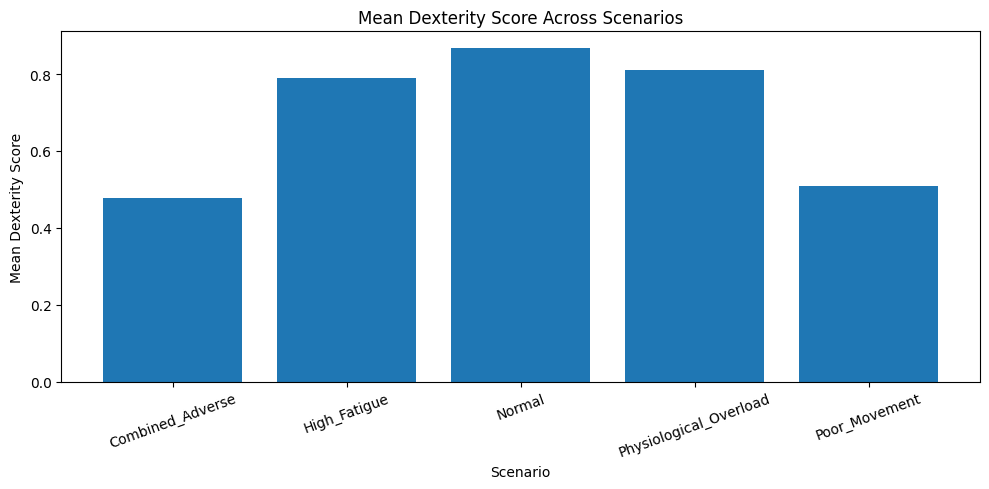

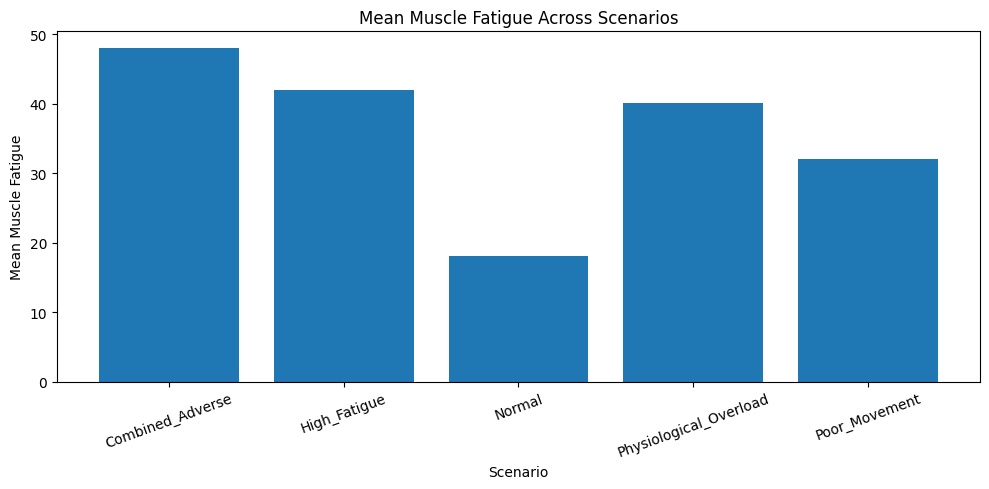

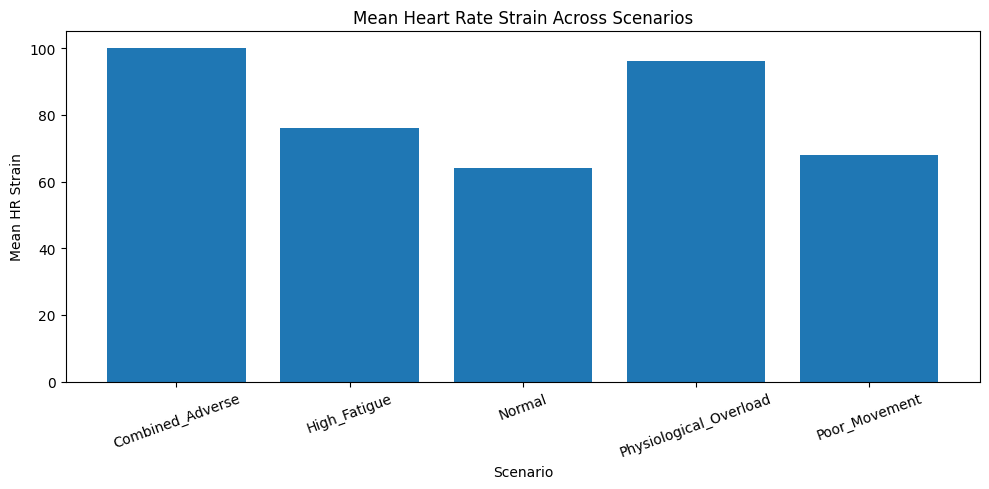

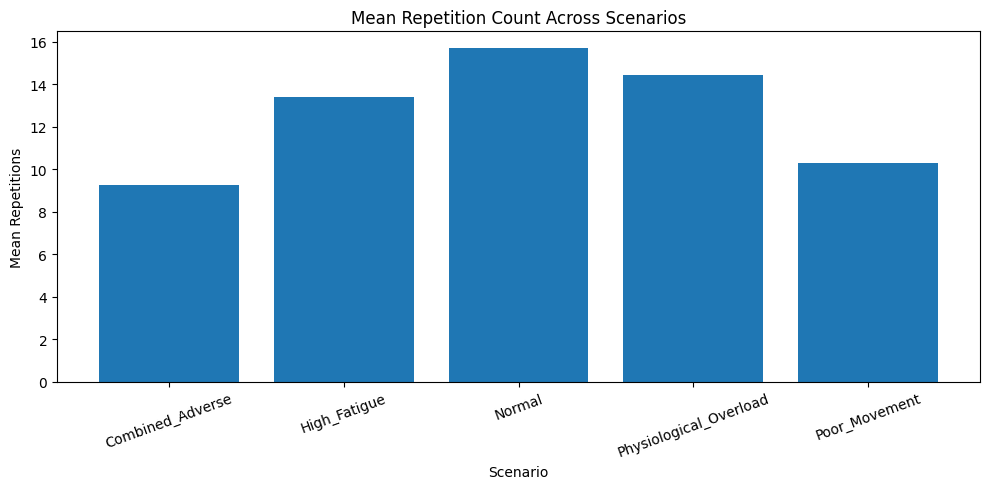

In [13]:
# STEP 12 — Cell 1
# Figure 4: Scenario-wise Sensor Behavior

import matplotlib.pyplot as plt
import pandas as pd

# Scenario-wise mean values
scenario_behavior = (
    df.groupby("scenario")
      .agg(
          Mean_Repetitions=("repetitionCount", "mean"),
          Mean_Dexterity=("dexterityScore", "mean"),
          Mean_Muscle_Fatigue=("muscleFatigue", "mean"),
          Mean_HR_Strain=("heartRateStrain", "mean")
      )
      .reset_index()
)

print("===== STEP 12: FIGURE 4 — SCENARIO-WISE SENSOR BEHAVIOR =====")
print()

print(
    scenario_behavior.to_string(
        index=False,
        formatters={
            "Mean_Repetitions": "{:.2f}".format,
            "Mean_Dexterity": "{:.4f}".format,
            "Mean_Muscle_Fatigue": "{:.2f}".format,
            "Mean_HR_Strain": "{:.2f}".format
        }
    )
)

print()
print("Numerical description:")
for _, row in scenario_behavior.iterrows():
    print(
        f"{row['scenario']}: "
        f"Repetitions={row['Mean_Repetitions']:.2f}, "
        f"Dexterity={row['Mean_Dexterity']:.4f}, "
        f"Fatigue={row['Mean_Muscle_Fatigue']:.2f}, "
        f"HR Strain={row['Mean_HR_Strain']:.2f}"
    )

# Plot 1 — Mean Dexterity
plt.figure(figsize=(10, 5))
plt.bar(
    scenario_behavior["scenario"],
    scenario_behavior["Mean_Dexterity"]
)
plt.title("Mean Dexterity Score Across Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Mean Dexterity Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot 2 — Mean Muscle Fatigue
plt.figure(figsize=(10, 5))
plt.bar(
    scenario_behavior["scenario"],
    scenario_behavior["Mean_Muscle_Fatigue"]
)
plt.title("Mean Muscle Fatigue Across Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Mean Muscle Fatigue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot 3 — Mean HR Strain
plt.figure(figsize=(10, 5))
plt.bar(
    scenario_behavior["scenario"],
    scenario_behavior["Mean_HR_Strain"]
)
plt.title("Mean Heart Rate Strain Across Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Mean HR Strain")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot 4 — Mean Repetitions
plt.figure(figsize=(10, 5))
plt.bar(
    scenario_behavior["scenario"],
    scenario_behavior["Mean_Repetitions"]
)
plt.title("Mean Repetition Count Across Scenarios")
plt.xlabel("Scenario")
plt.ylabel("Mean Repetitions")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

===== STEP 12: FIGURE 5 — CONFUSION MATRIX =====

Confusion Matrix:
                 Predicted
               No Alert   Alert
Actual Normal     13,213     46,987
Actual Adverse    54,515    186,285

Numerical interpretation:
- True Negatives  (TN): 13,213
- False Positives (FP): 46,987
- False Negatives (FN): 54,515
- True Positives  (TP): 186,285


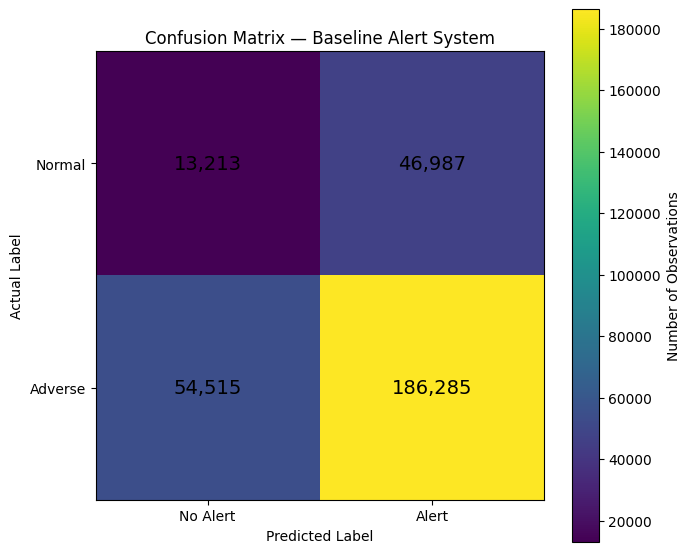

In [14]:
# STEP 12 — Cell 2
# Figure 5: Confusion Matrix

import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix using the already calculated values
cm = np.array([
    [TN, FP],
    [FN, TP]
])

print("===== STEP 12: FIGURE 5 — CONFUSION MATRIX =====")
print()

print("Confusion Matrix:")
print("                 Predicted")
print("               No Alert   Alert")
print(f"Actual Normal   {TN:>8,}   {FP:>8,}")
print(f"Actual Adverse  {FN:>8,}   {TP:>8,}")

print()
print("Numerical interpretation:")
print(f"- True Negatives  (TN): {TN:,}")
print(f"- False Positives (FP): {FP:,}")
print(f"- False Negatives (FN): {FN:,}")
print(f"- True Positives  (TP): {TP:,}")

# Plot
plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — Baseline Alert System")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Alert", "Alert"])
plt.yticks([0, 1], ["Normal", "Adverse"])

# Add numerical values inside cells
for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar(label="Number of Observations")
plt.tight_layout()
plt.show()